# 1.cleaning data

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_excel(r'/home/phatthapol/.vscode-server/ipst_project/data_depresstion.xlsx')
df

In [ ]:
df = df.drop(['ประทับเวลา','วันเดือนปี','ทำครั้งที่','ที่อยู่อีเมล','ห้อง','วันที่ทำ','แบบประเมิน','Unnamed: 8','Unnamed: 10'], axis=1)
df

In [ ]:
df = df.drop_duplicates()
df

In [ ]:
remove_strings = ['1)','2)','3)','4)','5)','1','2','3', '4','5','.','-']
for remove_str in remove_strings:
     df.loc[:, 'text'] = df['text'].str.replace(remove_str, '', regex=False)
df

In [ ]:
df.loc[:, 'text'] = df['text'].apply(lambda x: x.strip())
df

In [ ]:
df.loc[:, 'label'] = df['label'].replace('-', int(0))
df

In [ ]:
df.to_excel('cleaning data_depression.xlsx', index=False)

# 1.5 create sentense

## Synonym Replacement

In [ ]:
import nltk
nltk.download('wordnet')

In [ ]:
import pandas as pd

# โหลดไฟล์ Excel
file_path = r'/home/phatthapol/.vscode-server/ipst_project/cleaning data_depression.xlsx'
df = pd.read_excel(file_path)

# แสดงข้อมูลเบื้องต้น
df.head()


In [ ]:
import random
from nltk.corpus import wordnet
import pandas as pd

# ฟังก์ชันสำหรับ Synonym Replacement
def synonym_replacement(text, n):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if wordnet.synsets(word)]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if synonyms:
            synonym = synonyms[0].lemmas()[0].name()
            if synonym != random_word:
                new_words = [synonym if word == random_word else word for word in new_words]
                num_replaced += 1
        if num_replaced >= n:
            break
    sentence = ' '.join(new_words)
    return sentence

# สร้างข้อความใหม่สำหรับหมวดหมู่ 4 และ 5
def augment_data_synonym(df, label, target_count):
    current_count = len(df[df['label'] == label])
    new_texts = []
    while current_count + len(new_texts) < target_count:
        sample = df[df['label'] == label].sample(n=1).iloc[0]
        new_text = synonym_replacement(sample['text'], 1)  # แทนที่คำด้วย synonym 1 คำ
        new_texts.append({'text': new_text, 'label': label})
    return pd.DataFrame(new_texts)

# เพิ่มข้อมูลสำหรับหมวดหมู่ 4 และ 5
augmented_df_4_synonym = augment_data_synonym(df, 4, 550)
augmented_df_5_synonym = augment_data_synonym(df, 5, 550)

# รวมข้อมูลเดิมกับข้อมูลที่เพิ่มใหม่
df_augmented_synonym = pd.concat([df, augmented_df_4_synonym, augmented_df_5_synonym], ignore_index=True)

# บันทึกข้อมูลที่เพิ่มใหม่ลงในไฟล์ Excel
output_file_path = 'cleaned_data_depression_augmented_synonym.xlsx'
df_augmented_synonym.to_excel(output_file_path, index=False)


## สลับตำแหน่ง

In [ ]:
import random

# ฟังก์ชันสำหรับการสลับตำแหน่งคำ
def random_swap(text, n):
    words = text.split()
    if len(words) < 2:
        return text
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

# สร้างข้อความใหม่สำหรับหมวดหมู่ 4 และ 5
def augment_data_swap(df, label, target_count):
    current_count = len(df[df['label'] == label])
    new_texts = []
    while current_count + len(new_texts) < target_count:
        sample = df[df['label'] == label].sample(n=1).iloc[0]
        new_text = random_swap(sample['text'], 1)  # สลับตำแหน่งคำ 1 ครั้ง
        new_texts.append({'text': new_text, 'label': label})
    return pd.DataFrame(new_texts)

# เพิ่มข้อมูลสำหรับหมวดหมู่ 4 และ 5
augmented_df_4 = augment_data_swap(df, 4, 550)
augmented_df_5 = augment_data_swap(df, 5, 550)

# รวมข้อมูลเดิมกับข้อมูลที่เพิ่มใหม่
df_augmented = pd.concat([df, augmented_df_4, augmented_df_5], ignore_index=True)

# ตรวจสอบจำนวนข้อมูลในแต่ละหมวดหมู่หลังจากการเพิ่มข้อมูล
df_augmented_counts = df_augmented['label'].value_counts()
df_augmented_counts

# บันทึกข้อมูลที่เพิ่มใหม่ลงในไฟล์ Excel
output_file_path = 'cleaned_data_depression_augmented.xlsx'
df_augmented.to_excel(output_file_path, index=False)



# 2.wordtovector

In [1]:
import pandas as pd
df = pd.read_excel(r'/home/phatthapol/.vscode-server/ipst_project/cleaning data_depression.xlsx')
df

,text,label
0,ฉันเป็นคนมีความสุข,1.0
1,ฉันอยากทำหน้าที่ของตัวเองให้ดีกว่านี้,2.0
2,ชีวิตฉันนั้นเหนื่อยเหลือเกินตอนนี้,4.0
3,อนาคตของฉันจะต้องไม่เป็นภาระกับคนรอบตัว และไม่...,3.0
4,ฉันเป็นคนชอบแมวมากๆ,1.0
...,...,...
2580,ชีวิตซึมเศร้าของเรามีอยู่สองแบบเมื่อก่อน โลกโห...,5.0
2581,เคยโกดจนทำลายข้าวของมั้ย เราควรทำลายข้าวของหรื...,4.0
2582,ทุกวันนี้ฉันพยายามตายมากกว่าพยายามใช้ชีวิตเสียอีก,5.0
2583,ตอนนี้ยังไม่รู้ด้วยซ้ำว่าเราก้าวผ่านแต่ละวันมา...,4.0


In [2]:
df.groupby(['label']).count()

,text
label,
1.0,657
2.0,778
3.0,503
4.0,347
5.0,298


In [3]:
df.loc[:, 'label'] = df['label'].replace(1, int(0))
df.loc[:, 'label'] = df['label'].replace(2, int(1))
df.loc[:, 'label'] = df['label'].replace(3, int(2))
df.loc[:, 'label'] = df['label'].replace(4, int(3))
df.loc[:, 'label'] = df['label'].replace(5, int(4))
df

,text,label
0,ฉันเป็นคนมีความสุข,0.0
1,ฉันอยากทำหน้าที่ของตัวเองให้ดีกว่านี้,1.0
2,ชีวิตฉันนั้นเหนื่อยเหลือเกินตอนนี้,3.0
3,อนาคตของฉันจะต้องไม่เป็นภาระกับคนรอบตัว และไม่...,2.0
4,ฉันเป็นคนชอบแมวมากๆ,0.0
...,...,...
2580,ชีวิตซึมเศร้าของเรามีอยู่สองแบบเมื่อก่อน โลกโห...,4.0
2581,เคยโกดจนทำลายข้าวของมั้ย เราควรทำลายข้าวของหรื...,3.0
2582,ทุกวันนี้ฉันพยายามตายมากกว่าพยายามใช้ชีวิตเสียอีก,4.0
2583,ตอนนี้ยังไม่รู้ด้วยซ้ำว่าเราก้าวผ่านแต่ละวันมา...,3.0


In [4]:
df.groupby(['label']).count()

,text
label,
0.0,657
1.0,778
2.0,503
3.0,347
4.0,298


In [5]:
df_to_duplicate = df[df['label'].isin([3, 4])]
df = pd.concat([df, df_to_duplicate], ignore_index=True)
df

,text,label
0,ฉันเป็นคนมีความสุข,0.0
1,ฉันอยากทำหน้าที่ของตัวเองให้ดีกว่านี้,1.0
2,ชีวิตฉันนั้นเหนื่อยเหลือเกินตอนนี้,3.0
3,อนาคตของฉันจะต้องไม่เป็นภาระกับคนรอบตัว และไม่...,2.0
4,ฉันเป็นคนชอบแมวมากๆ,0.0
...,...,...
3225,ชีวิตซึมเศร้าของเรามีอยู่สองแบบเมื่อก่อน โลกโห...,4.0
3226,เคยโกดจนทำลายข้าวของมั้ย เราควรทำลายข้าวของหรื...,3.0
3227,ทุกวันนี้ฉันพยายามตายมากกว่าพยายามใช้ชีวิตเสียอีก,4.0
3228,ตอนนี้ยังไม่รู้ด้วยซ้ำว่าเราก้าวผ่านแต่ละวันมา...,3.0


In [6]:
df.groupby(['label']).count()

,text
label,
0.0,657
1.0,778
2.0,503
3.0,694
4.0,596


In [6]:
# ลบคำขึ้นต้น ฉันเป็น, คนรอบตัวฉัน, ฉันอยาก
df['text'] = df['text'].replace(r'^(ฉันเป็น|คนรอบตัวฉัน|ฉันอยาก|ชีวิตฉัน|อนาคตของฉัน|คนรอบตัวของฉัน)', '', regex=True)

In [7]:
text = ' '
for n in df['text']:
  text += ' ' + str(n)
text = text.strip()

In [8]:
text

"ฉันเป็นคนมีความสุข ฉันอยากทำหน้าที่ของตัวเองให้ดีกว่านี้ ชีวิตฉันนั้นเหนื่อยเหลือเกินตอนนี้ อนาคตของฉันจะต้องไม่เป็นภาระกับคนรอบตัว และไม่เดือดร้อนตัวเอง มีอาชีพที่ทำแล้วมีความสุขแล้วได้เงินมากพอที่จะใช้โดยไม่ต้องคิดมาก ฉันพร้อมที่จะเสียสละบางสิ่งเล็กๆน้อยๆ เพื่อแลกกับอนาคตที่ฉันฝันไว้ ฉันเป็นคนชอบแมวมากๆ อนาคตของฉันคงจะได้ไปเที่ยวหลายๆประเทศ คนรอบตัวของฉันมีสไตล์การแต่งตัวที่แตกต่างกันไป ชีวิตฉันช่วงปิดเทอมมีแต่อะไรเดิมๆทุกวัน แต่ก็ยังไม่รู้สึกเบื่อ ฉันอยากได้ art toy ฉันอยากมาอีกจัง ฉันเป็นคนที่ชอบคิดมาก อนาคตของฉันจะมีไหมนะ คนรอบตัวของฉันรำคาญฉันรึเปล่า ชีวิตฉันควรมีรึเปล่า ฉันอยากหายไปเงียบๆไม่ต้องมีคนรู้ไม่ต้องมีคนตามหา ฉันอยากกินโมโม่ ฉันอยากเป็นคนรวยและสุขภาพดี ฉันอยากไปเที่ยวทะเล ฉันเป็นคนที่ผิดหวังเสมอ อนาคตฉันมันว่างเปล่า ฉันอยากนอนอยู่เฉยๆ ฉันเป็นคนอดทนเก่ง อนาคตของฉันขึ้นอยู่กับตัวเอง คนรอบตัวของฉันมีแต่คนเก่ง ชีวิตฉันยากเหลือเกิน ฉันอยากกินของอร่อย ฉันอยากกินหมาล่า นีด(need)ของเผ็ดสุบๆ ฉันเป็นคนชัดเจนในตัวเอง อนาคตของฉัน ฉันเลือกเองได้ คนรอบตัวของฉันทุกคนเป็นคนน่ารัก ชีวิ

In [ ]:
#pip install pythainlp
#pip install marisa_trie

In [8]:
from pythainlp import word_tokenize
tokens = word_tokenize(text, engine='newmm',keep_whitespace=False)
tokens

['คน',
 'มีความสุข',
 'ทำหน้าที่',
 'ของ',
 'ตัวเอง',
 'ให้',
 'ดีกว่า',
 'นี้',
 'นั้น',
 'เหนื่อย',
 'เหลือเกิน',
 'ตอนนี้',
 'จะ',
 'ต้อง',
 'ไม่',
 'เป็น',
 'ภาระ',
 'กับ',
 'คน',
 'รอบตัว',
 'และ',
 'ไม่',
 'เดือดร้อน',
 'ตัวเอง',
 'มี',
 'อาชีพ',
 'ที่',
 'ทำ',
 'แล้ว',
 'มีความสุข',
 'แล้ว',
 'ได้เงิน',
 'มาก',
 'พอที่จะ',
 'ใช้',
 'โดย',
 'ไม่ต้อง',
 'คิดมาก',
 'ฉัน',
 'พร้อม',
 'ที่จะ',
 'เสียสละ',
 'บางสิ่ง',
 'เล็ก',
 'ๆ',
 'น้อย',
 'ๆ',
 'เพื่อ',
 'แลก',
 'กับ',
 'อนาคต',
 'ที่',
 'ฉัน',
 'ฝัน',
 'ไว้',
 'คน',
 'ชอบ',
 'แมว',
 'มาก',
 'ๆ',
 'คงจะ',
 'ได้',
 'ไปเที่ยว',
 'หลาย',
 'ๆ',
 'ประเทศ',
 'มี',
 'สไตล์',
 'การ',
 'แต่งตัว',
 'ที่',
 'แตก',
 'ต่างกัน',
 'ไป',
 'ช่วง',
 'ปิดเทอม',
 'มี',
 'แต่',
 'อะไร',
 'เดิม',
 'ๆ',
 'ทุกวัน',
 'แต่',
 'ก็',
 'ยัง',
 'ไม่',
 'รู้สึก',
 'เบื่อ',
 'ได้',
 'art',
 'toy',
 'มา',
 'อีก',
 'จัง',
 'คน',
 'ที่',
 'ชอบ',
 'คิดมาก',
 'จะ',
 'มี',
 'ไหม',
 'นะ',
 'รำคาญ',
 'ฉัน',
 'รึเปล่า',
 'ควร',
 'มี',
 'รึเปล่า',
 'หาย',
 'ไป',
 'เงียบๆ'

In [9]:
from pythainlp.corpus.common import thai_words,thai_stopwords
t_stop_words = [word for word in thai_stopwords()]
t_stop_words

['ขณะเดียวกัน',
 'กัน',
 'ก็แล้วแต่',
 'อย่างๆ',
 'คราที่',
 'เช่นใด',
 'อันๆ',
 'คล้าย',
 'นาง',
 'ด้วยเหมือนกัน',
 'พอกัน',
 'ยิ่ง',
 'คราวที่',
 'เกี่ยวกับ',
 'ทุกชิ้น',
 'นอกจาก',
 'พอสมควร',
 'แหละ',
 'ด้วยเพราะ',
 'แยะๆ',
 'มั้ยเนี่ย',
 'เช่นดังเก่า',
 'ที่ซึ่ง',
 'ตลอดศก',
 'ข้างล่าง',
 'นับจากนั้น',
 'กลุ่ม',
 'ส่วนเกิน',
 'ครั้งหลัง',
 'หากว่า',
 'เมื่อคราวก่อน',
 'นักๆ',
 'อย่างยิ่ง',
 'ยังคง',
 'เล็กน้อย',
 'ไม่ค่อยจะ',
 'แสดงว่า',
 'ทุกวัน',
 'ครั้ง',
 'ช้านาน',
 'ทำให้',
 'อยู่',
 'เขา',
 'ค่อนมาทาง',
 'เมื่อเย็น',
 'ตลอดระยะเวลา',
 'เถิด',
 'จด',
 'พอดี',
 'คราวไหน',
 'เช่นเดียวกัน',
 'ทุกแห่ง',
 'แต่ก่อน',
 'สุดๆ',
 'เช่นกัน',
 'ช่วงระหว่าง',
 'ทั้งนั้นด้วย',
 'เนี่ย',
 'ด้วยประการฉะนี้',
 'ได้แต่',
 'ทุกตัว',
 'แค่ไหน',
 'จวบ',
 'ก็ดี',
 'ทุกที่',
 'เห็นควร',
 'ช่วงหน้า',
 'จะ',
 'อย่างหนึ่ง',
 'นอกเหนือจาก',
 'ถูก',
 'ทีใด',
 'นั้นๆ',
 'ครบครัน',
 'เปิด',
 'อนึ่ง',
 'พวกที่',
 'ยอม',
 'นี่เอง',
 'บางแห่ง',
 'เป็นที่',
 'เล็กๆ',
 'เยอะแยะ',
 'เป็นเพราะ',
 'ดังเคย',
 'แค

In [10]:
tokens = [token for token in tokens if len(token)>1 and token not in t_stop_words]
tokens

['คน',
 'มีความสุข',
 'ทำหน้าที่',
 'ตัวเอง',
 'ดีกว่า',
 'เหนื่อย',
 'ตอนนี้',
 'ภาระ',
 'คน',
 'รอบตัว',
 'เดือดร้อน',
 'ตัวเอง',
 'อาชีพ',
 'ทำ',
 'มีความสุข',
 'ได้เงิน',
 'พอที่จะ',
 'ไม่ต้อง',
 'คิดมาก',
 'ที่จะ',
 'เสียสละ',
 'บางสิ่ง',
 'แลก',
 'อนาคต',
 'ฝัน',
 'คน',
 'ชอบ',
 'แมว',
 'ไปเที่ยว',
 'ประเทศ',
 'สไตล์',
 'แต่งตัว',
 'แตก',
 'ต่างกัน',
 'ปิดเทอม',
 'เดิม',
 'รู้สึก',
 'เบื่อ',
 'art',
 'toy',
 'คน',
 'ชอบ',
 'คิดมาก',
 'ไหม',
 'รำคาญ',
 'รึเปล่า',
 'รึเปล่า',
 'หาย',
 'เงียบๆ',
 'ไม่ต้อง',
 'คน',
 'รู้',
 'ไม่ต้อง',
 'คน',
 'ตามหา',
 'กิน',
 'โม',
 'โม่',
 'คนรวย',
 'สุขภาพ',
 'ดี',
 'ไปเที่ยว',
 'ทะเล',
 'คน',
 'ผิดหวัง',
 'เสมอ',
 'อนาคต',
 'ว่างเปล่า',
 'นอน',
 'คน',
 'อดทน',
 'เก่ง',
 'ขึ้นอยู่กับ',
 'ตัวเอง',
 'คนเก่ง',
 'กิน',
 'อร่อย',
 'กิน',
 'หมา',
 'ล่า',
 'นีด',
 '(need)',
 'เผ็ด',
 'สุ',
 'บๆ',
 'คน',
 'ชัดเจน',
 'ตัวเอง',
 'เลือก',
 'คน',
 'น่ารัก',
 'เลือก',
 'หา',
 'ความสุข',
 'เจอ',
 'คน',
 'ชอบ',
 'คนเดียว',
 'นิสัย',
 'ดี',
 'โชคดี',
 'มีครอบครัว

In [12]:
len(tokens)

14806

In [ ]:
from collections import Counter
c = Counter(tokens)
c=dict(c.most_common(50))
c

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wd=WordCloud(font_path=r'/home/phatthapol/.vscode-server/THSarabunNew.ttf',width=1800,height=1200,background_color='white').generate_from_frequencies(c)
plt.figure(figsize=(15,10))
plt.axis("off")
plt.imshow(wd, interpolation='bilinear')

In [12]:
#Random sample equally for each text
df = df.groupby('label')['text'].apply(lambda s: s.sample(500)).reset_index()
df = df[['text','label']]
df = df.sample(frac = 1) #Random dataset
print(df.groupby(['label']).count())

       text
label      
0.0     500
1.0     500
2.0     500
3.0     500
4.0     500


In [11]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

from pythainlp.tokenize import word_tokenize
from gensim.models import KeyedVectors
import numpy as np

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import dill as pickle
import pandas as pd

model_path = './'

In [13]:
from pythainlp import word_vector
model = word_vector.WordVector(model_name="thai2fit_wv").get_model()

In [14]:
thai2dict = {}
for word in model.index_to_key:
    thai2dict[word] = model[word]
thai2vec = pd.DataFrame.from_dict(thai2dict,orient='index')
thai2vec.head(10)

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
ที่,0.308956,-0.097699,0.116745,0.215612,0.015768,-0.064163,0.062168,0.039649,0.864940,0.846904,...,-0.142418,0.033241,0.171581,-0.624864,-0.009358,0.449131,0.120130,-0.122195,-0.450617,-0.071318
และ,0.010751,-0.618971,0.129665,0.035460,-0.007560,0.027607,0.397824,0.026543,0.254075,0.168328,...,-0.105786,0.180930,-0.101630,0.070885,-0.037263,0.183606,-0.049088,-0.672288,-1.293044,0.592576
เป็น,-0.015736,-0.258926,0.052953,0.153728,-0.005985,-0.021081,0.041088,0.057312,1.633230,0.442729,...,-0.009408,-0.252576,-0.305512,0.372542,0.049151,0.568470,0.266586,0.400800,-0.784650,0.197369
ของ,-0.189711,-0.174774,0.171124,-0.186771,0.054294,-0.114150,-1.109456,-0.094466,-0.447015,0.042377,...,-0.168676,-0.148738,0.680404,0.097702,0.020270,0.182967,-0.083949,0.006287,-0.707434,-0.070234
มี,-0.156962,-0.231863,0.080312,0.323157,0.215695,0.055145,0.420794,0.016842,0.256759,0.832864,...,-0.044267,-0.147186,-0.105424,0.907078,0.009299,0.550953,0.139337,0.031696,-0.670379,-0.008048
ได้,-0.428813,-0.031194,0.041922,-0.036608,-0.008106,0.076470,-0.782270,0.033361,0.606864,0.440520,...,0.024458,-0.025031,0.103389,-0.078255,0.034323,0.459774,-0.748643,0.337775,-0.487408,-0.511535
"""""""""",-0.287710,0.064193,0.205076,0.146356,-0.071343,-0.039451,-1.845461,0.163763,1.018096,0.272786,...,0.051024,-0.532856,-0.131856,-0.090323,-0.058895,0.151262,-0.420358,0.055971,-0.930814,0.163908
การ,0.239587,-0.303620,0.079953,-0.453045,-0.528826,-0.161692,0.235725,-0.099673,0.691668,0.536159,...,-0.110436,-0.297495,-0.217414,0.045158,0.066647,0.190095,-0.304333,-0.724927,-0.995488,-0.716609
(,-0.120522,-0.355783,0.168180,-0.377733,-0.158624,-0.047249,0.361140,0.161460,0.913314,0.345037,...,0.116285,-0.318218,-0.356664,0.519889,0.130475,0.125772,0.101328,-0.382658,-1.205359,0.340139
),-0.086848,-0.155231,0.133015,-0.039913,0.183761,0.115142,-1.940854,-0.066565,-2.399744,0.146722,...,0.019406,-0.181474,0.099863,0.516092,0.201697,0.249139,0.252957,1.138815,-0.018209,0.232265


In [15]:
print(thai2vec)
thai2vec.shape

                 0         1         2         3         4         5    \
ที่         0.308956 -0.097699  0.116745  0.215612  0.015768 -0.064163   
และ         0.010751 -0.618971  0.129665  0.035460 -0.007560  0.027607   
เป็น       -0.015736 -0.258926  0.052953  0.153728 -0.005985 -0.021081   
ของ        -0.189711 -0.174774  0.171124 -0.186771  0.054294 -0.114150   
มี         -0.156962 -0.231863  0.080312  0.323157  0.215695  0.055145   
...              ...       ...       ...       ...       ...       ...   
ไลต์ฟ       0.003361 -0.016570 -0.087134  0.010009 -0.024552 -0.023878   
ไหนว่า      0.004052 -0.017273 -0.086782  0.009518 -0.024050 -0.024528   
ไอซ์ที      0.003284 -0.018590 -0.087451  0.010155 -0.024508 -0.022246   
ไอบูโปรเฟน  0.001181 -0.018887 -0.089136  0.010626 -0.025262 -0.022990   
ไออุ่น      0.003489 -0.017758 -0.086213  0.009525 -0.023742 -0.022018   

                 6         7         8         9    ...       290       291  \
ที่         0.062168  0.039649  

(51358, 300)

In [16]:
thai2dict = list(thai2dict)
thai2dict

['ที่',
 'และ',
 'เป็น',
 'ของ',
 'มี',
 'ได้',
 '""""',
 'การ',
 '(',
 ')',
 'โดย',
 'ส',
 'น',
 'กับ',
 'จะ',
 'ปี',
 'ว่า',
 'จาก',
 ',',
 'ซึ่ง',
 'ให้',
 '',
 'พ.ศ.',
 'ไป',
 '.',
 'อ',
 '-',
 'เมื่อ',
 'มา',
 '์',
 'หรือ',
 'พระ',
 'ก็',
 'อยู่',
 'ร์',
 'นี้',
 'คือ',
 'เ',
 'แต่',
 'ใช้',
 'ค.ศ.',
 'ยัง',
 'คน',
 'ด้วย',
 'เขา',
 'วันที่',
 'ถูก',
 'ไม่',
 'แห่ง',
 'เพื่อ',
 'ๆ',
 'จึง',
 'ทาง',
 'ขึ้น',
 ':',
 '2',
 'ได้รับ',
 'นั้น',
 '1',
 'ผู้',
 'สามารถ',
 'แล้ว',
 'ท',
 'เมือง',
 'ล',
 'บ',
 'ช',
 'กัน',
 'ทำให้',
 '3',
 'ประเทศ',
 'ถึง',
 'ทรง',
 'เธอ',
 'หนึ่ง',
 'ชื่อ',
 'เรื่อง',
 'เพลง',
 'ิ',
 'สร้าง',
 'ะ',
 'ออก',
 'ตาม',
 'ต่อ',
 'เกิด',
 'ไทย',
 'แบบ',
 'ต้อง',
 '()',
 'อีก',
 'ทั้ง',
 'ต่อมา',
 'the',
 'ระหว่าง',
 'จังหวัด',
 'ริ',
 'เอ',
 'ส่วน',
 'ณ',
 'ความ',
 'ทำ',
 'ปัจจุบัน',
 'ี',
 'พระองค์',
 '4',
 'เช่น',
 'แรก',
 'นา',
 'มิ',
 'ลง',
 'มาก',
 'สำหรับ',
 '%',
 'เรียก',
 'รี',
 'ด้าน',
 'พบ',
 'เด',
 'กลุ่ม',
 'ตัว',
 'ทีม',
 'โรงเรียน',
 'เซ',
 'ใหม่',


In [17]:
import pythainlp.corpus
stop_words = set(pythainlp.corpus.common.thai_stopwords())

def xidx(x):
  x_idx = []
  heading = word_tokenize(x)
  # Remove all syntax (need to download nltk.punkt)
  w = [word for word in heading if word.isalnum()]
  # Remove stopping words
  w = [word for word in w if not word in stop_words]
  for h in heading:
    if h in thai2dict:
      x_idx.append(thai2dict.index(h))
  return np.array(x_idx)

In [18]:
# Data length adjustment for neural network
Xtrain_idx = []
max_len = 0

for x, i in zip(df['text'], range(len(df['text']))):
  if i % 100 == 0:
    print(f'heading process... {i}')
  Xtrain_idx.append(xidx(x))
  if len(Xtrain_idx[-1]) > max_len:
    max_len = len(Xtrain_idx[-1])
  
print(max_len)

heading process... 0
heading process... 100
heading process... 200
heading process... 300
heading process... 400
heading process... 500
heading process... 600
heading process... 700
heading process... 800
heading process... 900
heading process... 1000
heading process... 1100
heading process... 1200
heading process... 1300
heading process... 1400
heading process... 1500
heading process... 1600
heading process... 1700
heading process... 1800
heading process... 1900
heading process... 2000
heading process... 2100
heading process... 2200
heading process... 2300
heading process... 2400
94


In [19]:
# Zero padding for vocab list
thai2dict = [''] + thai2dict
print(len(thai2dict))

# Zero padding with random for word vector
rand_vec = np.random.rand(thai2vec.shape[1])  # Generate random vector with the same shape as thai2vec[0]
thai2vec = np.vstack((rand_vec, thai2vec))
print(thai2vec.shape)

51359
(51359, 300)


In [20]:
for i, x in zip(range(len(Xtrain_idx)), Xtrain_idx):
  if i % 100 == 0:
    print(f'padding process... {i}')
  if len(x) < max_len:
    Xtrain_idx[i] = np.hstack((x, np.zeros(max_len - len(x))))

# Convert to numpy array for neural network
Xtrain_idx = np.array(Xtrain_idx)
Xtrain_idx

padding process... 0
padding process... 100
padding process... 200
padding process... 300
padding process... 400
padding process... 500
padding process... 600
padding process... 700
padding process... 800
padding process... 900
padding process... 1000
padding process... 1100
padding process... 1200
padding process... 1300
padding process... 1400
padding process... 1500
padding process... 1600
padding process... 1700
padding process... 1800
padding process... 1900
padding process... 2000
padding process... 2100
padding process... 2200
padding process... 2300
padding process... 2400


array([[  23., 1307.,    0., ...,    0.,    0.,    0.],
       [5275.,  110.,   50., ...,    0.,    0.,    0.],
       [  42.,  496., 2584., ...,    0.,    0.,    0.],
       ...,
       [  42.,  989.,    0., ...,    0.,    0.,    0.],
       [1487.,  552., 1460., ...,    0.,    0.,    0.],
       [1563.,    0., 2336., ...,    0.,    0.,    0.]])

In [4]:
import pandas as pd
from pythainlp import word_tokenize
from pythainlp.corpus.common import thai_stopwords
import numpy as np
from pythainlp.tokenize import word_tokenize
from pythainlp import word_vector

# โหลดข้อมูล
df = pd.read_excel(r'/home/phatthapol/.vscode-server/ipst_project/cleaning data_depression.xlsx')

# แปลง label
df['label'] = df['label'].replace({1: 0, 2: 1, 3: 2, 4: 3, 5: 4})

# เพิ่มข้อมูล
df_to_duplicate = df[df['label'].isin([3, 4])]
df = pd.concat([df, df_to_duplicate], ignore_index=True)



# ทำการ tokenization
text = ' '.join(df['text'])
tokens = word_tokenize(text, engine='newmm', keep_whitespace=False)
stop_words = set(thai_stopwords())
tokens = [token for token in tokens if len(token) > 1 and token not in stop_words]

# สุ่มตัวอย่างข้อมูล
df = df.groupby('label')['text'].apply(lambda s: s.sample(500)).reset_index()
df = df[['text', 'label']].sample(frac=1)

# โหลดเวกเตอร์คำ
model = word_vector.WordVector(model_name="thai2fit_wv").get_model()
thai2dict = {word: model[word] for word in model.index_to_key}
thai2vec = pd.DataFrame.from_dict(thai2dict, orient='index')
thai2dict = list(thai2dict)

# ฟังก์ชันสร้างเวกเตอร์คำ
def xidx(x):
    x_idx = []
    heading = word_tokenize(x)
    w = [word for word in heading if word.isalnum()]
    w = [word for word in w if word not in stop_words]
    for h in heading:
        if h in thai2dict:
            x_idx.append(thai2dict.index(h))
    return np.array(x_idx)

# เตรียมข้อมูลสำหรับโมเดล
Xtrain_idx = []
max_len = 0
for x in df['text']:
    Xtrain_idx.append(xidx(x))
    if len(Xtrain_idx[-1]) > max_len:
        max_len = len(Xtrain_idx[-1])

thai2dict = [''] + thai2dict
rand_vec = np.random.rand(thai2vec.shape[1])
thai2vec = np.vstack((rand_vec, thai2vec))

for i, x in enumerate(Xtrain_idx):
    if len(x) < max_len:
        Xtrain_idx[i] = np.hstack((x, np.zeros(max_len - len(x))))
Xtrain_idx = np.array(Xtrain_idx)


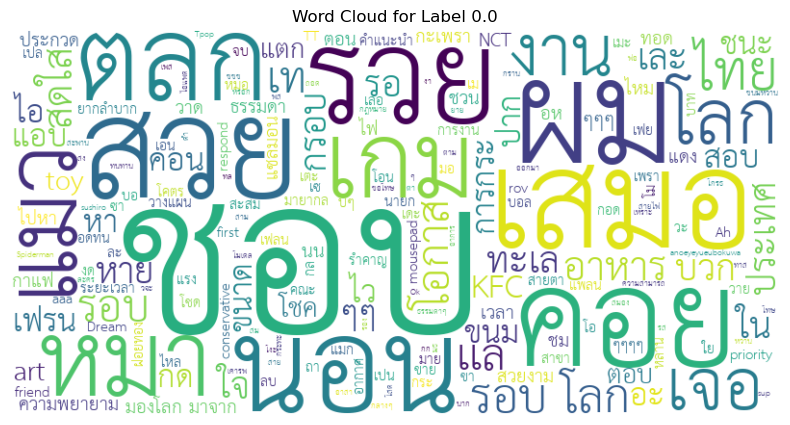

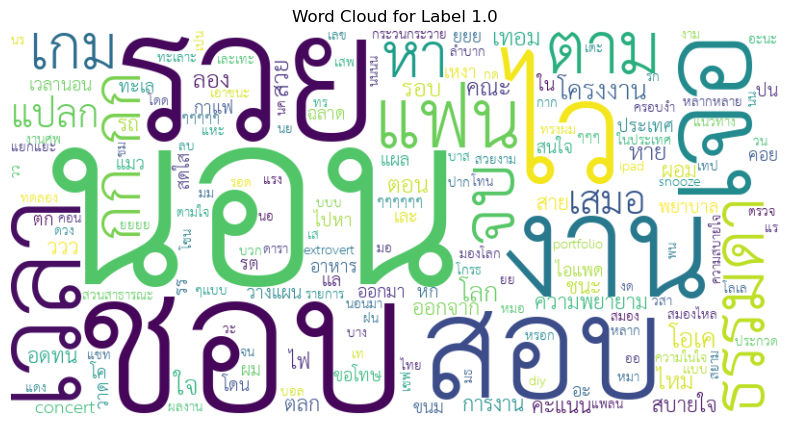

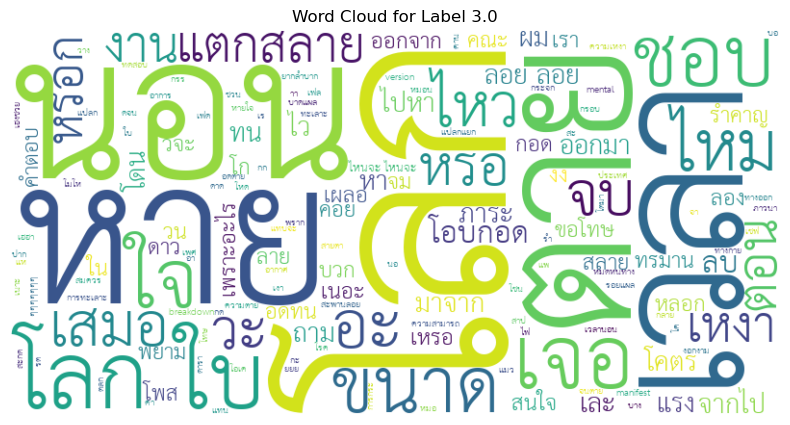

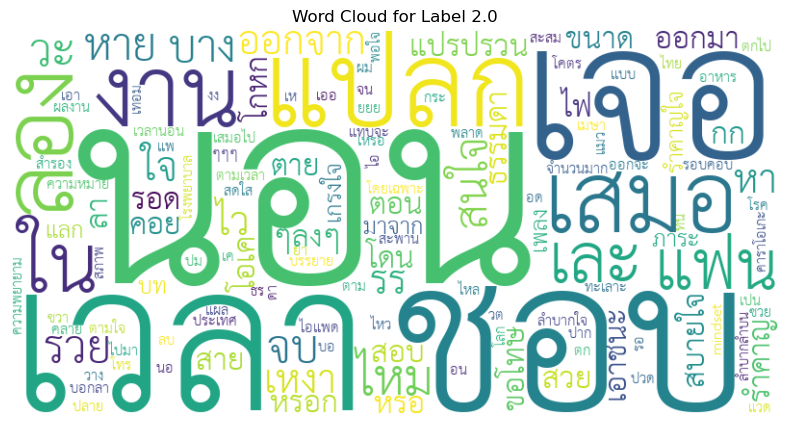

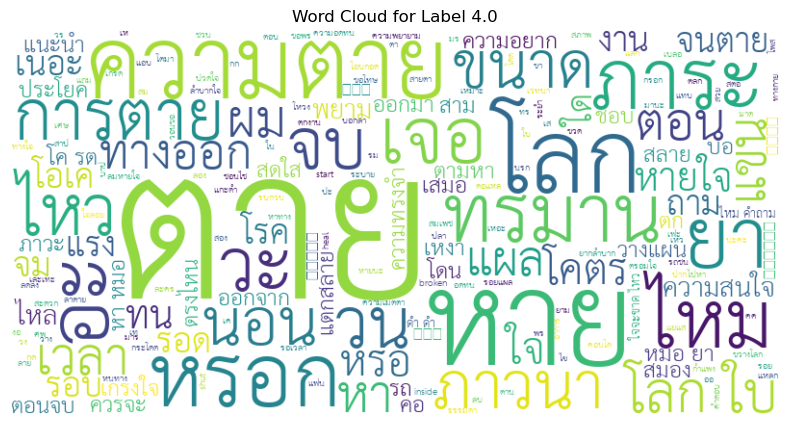

/tmp/ipykernel_1086/3388140715.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('label').apply(lambda x: x.sample(n=500, random_state=42)).reset_index(drop=True)


(1279, 17, 300)
(1279,)


In [46]:
import pandas as pd
from pythainlp import word_tokenize
from pythainlp.corpus.common import thai_stopwords
import numpy as np
from pythainlp.tokenize import word_tokenize
from pythainlp import word_vector
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# โหลดข้อมูล
df = pd.read_excel(r'/home/phatthapol/.vscode-server/ipst_project/cleaning data_depression.xlsx')

# กรองข้อมูลที่มี NaN ออก
df = df.dropna(subset=['text', 'label'])

# แปลง label
df['label'] = df['label'].replace({1: 0, 2: 1, 3: 2, 4: 3, 5: 4})

# เพิ่มข้อมูล
df_to_duplicate = df[df['label'].isin([3, 4])]
df = pd.concat([df, df_to_duplicate], ignore_index=True)

# คำที่ต้องการลบออก
words_to_remove = {'ทำ', 'อนาคต', 'คนรอบตัว', 'คน'}

# สร้าง Word Cloud พร้อมลบคำที่ไม่ต้องการ
def generate_wordcloud(text, label):
    for word in words_to_remove:
        text = text.replace(word, '')  # ลบคำที่ไม่ต้องการออก
    wordcloud = WordCloud(font_path='/home/phatthapol/.vscode-server/THSarabunNew.ttf', width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Label {label}")
    plt.show()

# สร้าง Word Cloud สำหรับแต่ละ label
for label in df['label'].unique():
    text = ' '.join(df[df['label'] == label]['text'])
    tokens = word_tokenize(text, engine='newmm', keep_whitespace=False)
    filtered_tokens = [token for token in tokens if len(token) > 1 and token.isalnum() and token not in stop_words and token not in words_to_remove]
    filtered_text = ' '.join(filtered_tokens)
    if filtered_text.strip():  # ตรวจสอบว่าข้อความไม่ว่างเปล่า
        generate_wordcloud(filtered_text, label)

# สุ่มตัวอย่าง label ละ 500 ตัวอย่าง หลังจากสร้าง Word Cloud
df_sampled = df.groupby('label').apply(lambda x: x.sample(n=500, random_state=42)).reset_index(drop=True)

# โหลดเวกเตอร์คำ
model = word_vector.WordVector(model_name="thai2fit_wv").get_model()
thai2dict = {word: model[word] for word in model.index_to_key}
thai2vec = pd.DataFrame.from_dict(thai2dict, orient='index')

# ฟังก์ชันสร้างเวกเตอร์คำ
def xidx(x):
    tokens = word_tokenize(x, engine='newmm', keep_whitespace=False)
    tokens = [token for token in tokens if len(token) > 1 and token.isalnum() and token not in stop_words and token not in words_to_remove]
    x_idx = [thai2dict.get(token) for token in tokens if token in thai2dict]
    return np.array(x_idx)

# เตรียมข้อมูลสำหรับโมเดล
Xtrain_idx = []
labels_valid = []  # สร้าง list ใหม่สำหรับ labels ที่สอดคล้องกับ Xtrain_idx
max_len = 0
vector_dim = model.vector_size  # ขนาดของเวกเตอร์คำ

for idx, x in enumerate(df_sampled['text']):
    x_token_idx = xidx(x)
    if len(x_token_idx) > 0:  # ตรวจสอบว่ามีเวกเตอร์ในรายการหรือไม่
        Xtrain_idx.append(x_token_idx)
        labels_valid.append(df_sampled['label'].iloc[idx])  # เก็บ label ที่สอดคล้องกับข้อมูลนี้
        if len(x_token_idx) > max_len:
            max_len = len(x_token_idx)

# เติมค่าศูนย์ให้ความยาวเวกเตอร์เท่ากัน
Xtrain_idx_padded = []
for vector in Xtrain_idx:
    if len(vector) < max_len:
        # เติมศูนย์ให้กับเวกเตอร์ที่มีขนาดเล็กกว่า
        padding = np.zeros((max_len - len(vector), vector_dim))
        vector = np.vstack((vector, padding))
    Xtrain_idx_padded.append(vector)

Xtrain_idx_padded = np.array(Xtrain_idx_padded)
labels = np.array(labels_valid)  # ใช้ labels_valid ที่ถูกสร้างใหม่

# บันทึกข้อมูลลงในไฟล์ .npz
np.savez('data2.npz', Xtrain_idx=Xtrain_idx_padded, labels=labels)

# โหลดข้อมูลจากไฟล์ .npz เพื่อตรวจสอบ
data = np.load('data2.npz')
print(data['Xtrain_idx'].shape)
print(data['labels'].shape)


In [43]:
df['label'].unique()

array([ 0.,  1.,  3.,  2.,  4., nan])

In [31]:
labels = df['label'].values

# บันทึกข้อมูลลงในไฟล์ .npz
np.savez('data2.npz', Xtrain_idx=Xtrain_idx_padded, labels=labels)

# โหลดข้อมูลจากไฟล์ .npz เพื่อตรวจสอบ
data = np.load('data2.npz')
print(data['Xtrain_idx'])
print(data['labels'])


[[[-0.60695398  0.48888999  0.065101   ...  0.66320503 -0.47264501
   -0.287729  ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  ...
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]]

 [[-0.017341   -0.119742    0.45640701 ... -0.068157   -0.009465
   -0.075013  ]
  [-0.070423   -0.087241    0.023359   ... -0.20622499  0.061204
   -0.080768  ]
  [-0.60695398  0.48888999  0.065101   ...  0.66320503 -0.47264501
   -0.287729  ]
  ...
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]]

 [[-0.60695398  0.48888999  0.065101   ...  0.66320503 -

In [37]:
# กำหนดสัดส่วน validation
validation_split = 0.25
num_val_samples = int(validation_split * Xtrain_idx_padded.shape[0])

# แยกข้อมูลเป็น train/validation
X_val_idx = Xtrain_idx_padded[:num_val_samples]
X_train_idx = Xtrain_idx_padded[num_val_samples:]
y_val = np.array(df['label'])[:num_val_samples]
y_train = np.array(df['label'])[num_val_samples:]

# บันทึกข้อมูลลงไฟล์ .npz
np.savez('prepared_data2_0.25.npz', X_train_idx=X_train_idx, y_train=y_train, X_val_idx=X_val_idx, y_val=y_val, thai2vec=thai2vec, max_len=max_len)


# 3.train model

## LSTM

In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Set GPU memory limit
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=7168)])
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPU,", len(logical_gpus), "Logical GPU")
    except RuntimeError as e:
        print(e)

# Define the input shape
input_length = max_len  # This should be the maximum length of your input sequences

# Define a function to create the model
def create_model(lstm_units1=64, lstm_units2=32, dense_units=24, dropout_rate1=0.5, dropout_rate2=0.5, learning_rate=0.001, l2_reg=0.01):
    model = Sequential()
    model.add(Embedding(input_dim=thai2vec.shape[0], output_dim=thai2vec.shape[1], input_length=input_length, name='embed_layer'))
    model.add(Bidirectional(LSTM(lstm_units1, return_sequences=True)))
    model.add(Dropout(dropout_rate1))
    model.add(Bidirectional(LSTM(lstm_units2)))
    model.add(Dropout(dropout_rate2))
    model.add(Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(Dropout(dropout_rate2))
    model.add(Dense(5, activation='softmax'))
    
    optz = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optz, metrics=['accuracy'])
    
    # Set weights for the embedding layer
    model.get_layer('embed_layer').set_weights([thai2vec])
    model.get_layer('embed_layer').trainable = True
    
    return model

# Split the data
validation_split = 0.3
num_val_samples = int(validation_split * Xtrain_idx.shape[0])
X_val_idx = Xtrain_idx[:num_val_samples]
X_train_idx = Xtrain_idx[num_val_samples:]
y_val = np.array(df['label'])[:num_val_samples]
y_train = np.array(df['label'])[num_val_samples:]

# Wrap the model using KerasClassifier
model = KerasClassifier(model=create_model, lstm_units1=64, lstm_units2=32, dense_units=24, dropout_rate1=0.5, dropout_rate2=0.5, learning_rate=0.001, l2_reg=0.01, epochs=10, batch_size=32, verbose=1)

# Define the hyperparameters grid to search
param_grid = {
    'model__lstm_units1': [32, 64, 128],
    'model__lstm_units2': [16, 32, 64],
    'model__dense_units': [16, 24, 32],
    'model__dropout_rate1': [0.3, 0.5, 0.7],
    'model__dropout_rate2': [0.3, 0.5, 0.7],
    'model__learning_rate': [0.001, 0.01, 0.1],
    'model__l2_reg': [0.001, 0.01, 0.1],
    'batch_size': [32, 64],
    'epochs': [10, 20, 30]
}

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Perform GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)
grid_result = grid.fit(X_train_idx, y_train, validation_data=(X_val_idx, y_val), callbacks=[early_stopping])

# Get the best model and its parameters
best_model = grid_result.best_estimator_
best_params = grid_result.best_params_
print("Best parameters found: ", best_params)

# Evaluate the best model on the validation set
val_pred = best_model.predict(X_val_idx)
val_cf_matrix = confusion_matrix(y_val, val_pred)

# Plot confusion matrix for validation set
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Validation Set)')
sns.heatmap(val_cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report for the validation set
report = classification_report(y_val, val_pred)
print(f'Classification Report (Validation Set): \n{report}')


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# โหลดข้อมูลที่เตรียมไว้
data = np.load(r'/home/phatthapol/.vscode-server/ipst_project/prepared_data.npz')
X_train_idx = data['X_train_idx']
y_train = data['y_train']
X_val_idx = data['X_val_idx']
y_val = data['y_val']
thai2vec = data['thai2vec']
max_len = data['max_len']

# สร้างโมเดล LSTM
input_length = int(max_len)
model = Sequential([
    Embedding(input_dim=thai2vec.shape[0], output_dim=thai2vec.shape[1], input_length=input_length, name='embed_layer'),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.55),
    Bidirectional(LSTM(64)),
    Dropout(0.6),
    Dense(42, activation='relu', kernel_regularizer=l2(0.02)),
    Dropout(0.55),
    Dense(5, activation='softmax')
])

optz = tf.keras.optimizers.Adam(learning_rate=0.0007)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optz, metrics=['accuracy'])
model.build(input_shape=(None, input_length))
model.summary()

model.get_layer('embed_layer').set_weights([thai2vec])
model.get_layer('embed_layer').trainable = True

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)

logs = model.fit(X_train_idx, y_train, epochs=30, batch_size=128, validation_data=(X_val_idx, y_val), callbacks=[early_stopping, reduce_lr])


In [ ]:
import matplotlib.pyplot as plt

# Check available styles
print(plt.style.available)

# Plot training history: accuracy
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(logs.history['accuracy'], c='royalblue', linewidth=2.5, label='Training accuracy')
    plt.plot(logs.history['val_accuracy'], c='forestgreen', linestyle='--', label='Validation accuracy')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

# Plot training history: loss
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(logs.history['loss'], c='royalblue', linewidth=2.5, label='Training loss')
    plt.plot(logs.history['val_loss'], c='forestgreen', linestyle='--', label='Validation loss')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# Prediction and performance for the training set
train_pred = model.predict(X_train_idx).argmax(axis=1)
train_cf_matrix = confusion_matrix(y_train, train_pred)

# Plot confusion matrix for training set
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Training Set)')
sns.heatmap(train_cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

val_pred = model.predict(X_val_idx).argmax(axis=1)
cf_matrix = confusion_matrix(y_val, val_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Validation Set)')
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
report = classification_report(y_val, val_pred)
print(f'Classification Report: \n{report}')

In [ ]:
model.save('LSTM.h5')

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import random
from pythainlp.corpus.common import thai_stopwords
from pythainlp.tokenize import word_tokenize
from pythainlp.corpus import wordnet

# เปิดใช้งาน mixed precision
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# โหลดข้อมูลที่เตรียมไว้
data = np.load(r'/home/phatthapol/.vscode-server/ipst_project/prepared_data.npz')
X_train_idx = data['X_train_idx']
y_train = data['y_train']
X_val_idx = data['X_val_idx']
y_val = data['y_val']
thai2vec = data['thai2vec']
max_len = data['max_len']

# สร้างฟังก์ชัน Data Augmentation
stop_words = set(thai_stopwords())

def get_synonyms(word):
    synsets = wordnet.synsets(word)
    synonyms = set()
    for syn in synsets:
        for lemma in syn.lemma_names():
            synonyms.add(lemma)
    if word in synonyms:
        synonyms.remove(word)
    return synonyms

def synonym_replacement(sentence, n):
    words = word_tokenize(sentence)
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word not in stop_words]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = get_synonyms(random_word)
        if len(synonyms) >= 1:
            synonym = random.choice(list(synonyms))
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

def random_insertion(sentence, n):
    words = word_tokenize(sentence)
    new_words = words.copy()
    for _ in range(n):
        add_word(new_words)
    return ' '.join(new_words)

def add_word(new_words):
    synonyms = []
    counter = 0
    while len(synonyms) < 1:
        random_word = new_words[random.randint(0, len(new_words) - 1)]
        synonyms = get_synonyms(random_word)
        counter += 1
        if counter >= 10:
            return
    random_synonym = random.choice(list(synonyms))
    random_idx = random.randint(0, len(new_words) - 1)
    new_words.insert(random_idx, random_synonym)

def random_swap(sentence, n):
    words = word_tokenize(sentence)
    new_words = words.copy()
    for _ in range(n):
        new_words = swap_word(new_words)
    return ' '.join(new_words)

def swap_word(new_words):
    random_idx_1 = random.randint(0, len(new_words) - 1)
    random_idx_2 = random_idx_1
    counter = 0
    while random_idx_2 == random_idx_1:
        random_idx_2 = random.randint(0, len(new_words) - 1)
        counter += 1
        if counter > 3:
            return new_words
    new_words[random_idx_1], new_words[random_idx_2] = new_words[random_idx_2], new_words[random_idx_1]
    return new_words

def random_deletion(sentence, p):
    words = word_tokenize(sentence)
    if len(words) == 1:
        return sentence
    new_words = []
    for word in words:
        r = random.uniform(0, 1)
        if r > p:
            new_words.append(word)
    if len(new_words) == 0:
        rand_int = random.randint(0, len(words) - 1)
        return words[rand_int]
    return ' '.join(new_words)

def augment_data(sentences, labels, num_aug=4):
    augmented_sentences = []
    augmented_labels = []
    for sentence, label in zip(sentences, labels):
        augmented_sentences.append(sentence)
        augmented_labels.append(label)
        for _ in range(num_aug):
            aug_sentence = sentence
            if random.uniform(0, 1) > 0.5:
                aug_sentence = synonym_replacement(aug_sentence, n=random.randint(1, 3))
            if random.uniform(0, 1) > 0.5:
                aug_sentence = random_insertion(aug_sentence, n=random.randint(1, 3))
            if random.uniform(0, 1) > 0.5:
                aug_sentence = random_swap(aug_sentence, n=random.randint(1, 3))
            if random.uniform(0, 1) > 0.5:
                aug_sentence = random_deletion(aug_sentence, p=random.uniform(0.1, 0.3))
            augmented_sentences.append(aug_sentence)
            augmented_labels.append(label)
    return augmented_sentences, augmented_labels

# ใช้ augment_data เพื่อสร้างข้อมูลใหม่
augmented_sentences, augmented_labels = augment_data(X_train_idx, y_train)

# สมมติว่า word_to_idx เป็นพจนานุกรมที่แมปคำกับดัชนีของมัน
word_to_idx = {word: idx for idx, word in enumerate(thai2vec)}

# แปลง augmented_sentences กลับเป็นดัชนีของเวกเตอร์คำ
augmented_sentences_idx = [[word_to_idx.get(word, 1) for word in word_tokenize(sentence)] for sentence in augmented_sentences]

# ปรับรูปแบบของข้อมูลให้เหมาะสม
augmented_sentences_idx = tf.keras.preprocessing.sequence.pad_sequences(augmented_sentences_idx, maxlen=max_len, padding='post')

# เปลี่ยน augmented_labels ให้เป็น array
augmented_labels = np.array(augmented_labels)

# สร้างโมเดล LSTM
input_length = int(max_len)
model = Sequential([
    Embedding(input_dim=thai2vec.shape[0], output_dim=thai2vec.shape[1], input_length=input_length, name='embed_layer'),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.55),
    Bidirectional(LSTM(64)),
    Dropout(0.6),
    Dense(42, activation='relu', kernel_regularizer=l2(0.02)),
    Dropout(0.55),
    Dense(5, activation='softmax', dtype='float32')  # output layer should be float32
])

optz = tf.keras.optimizers.Adam(learning_rate=0.0007)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optz, metrics=['accuracy'])
model.build(input_shape=(None, input_length))
model.summary()

model.get_layer('embed_layer').set_weights([thai2vec])
model.get_layer('embed_layer').trainable = True

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)

logs = model.fit(augmented_sentences_idx, augmented_labels, epochs=100, batch_size=,
                 validation_data=(X_val_idx, y_val), callbacks=[early_stopping, reduce_lr])


In [ ]:
import matplotlib.pyplot as plt

# Check available styles
print(plt.style.available)

# Plot training history: accuracy
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(logs.history['accuracy'], c='royalblue', linewidth=2.5, label='Training accuracy')
    plt.plot(logs.history['val_accuracy'], c='forestgreen', linestyle='--', label='Validation accuracy')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

# Plot training history: loss
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(logs.history['loss'], c='royalblue', linewidth=2.5, label='Training loss')
    plt.plot(logs.history['val_loss'], c='forestgreen', linestyle='--', label='Validation loss')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# Prediction and performance for the training set
train_pred = model.predict(X_train_idx).argmax(axis=1)
train_cf_matrix = confusion_matrix(y_train, train_pred)

# Plot confusion matrix for training set
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Training Set)')
sns.heatmap(train_cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

val_pred = model.predict(X_val_idx).argmax(axis=1)
cf_matrix = confusion_matrix(y_val, val_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Validation Set)')
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
report = classification_report(y_val, val_pred)
print(f'Classification Report: \n{report}')

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# โหลดข้อมูลที่เตรียมไว้
data = np.load(r'/home/phatthapol/.vscode-server/ipst_project/prepared_data.npz')
X_train_idx = data['X_train_idx']
y_train = data['y_train']
X_val_idx = data['X_val_idx']
y_val = data['y_val']
thai2vec = data['thai2vec']
max_len = data['max_len']

# สร้างโมเดล CNN
input_length = int(max_len)
model = Sequential([
    Embedding(input_dim=thai2vec.shape[0], output_dim=thai2vec.shape[1], input_length=input_length, name='embed_layer'),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(42, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

optz = tf.keras.optimizers.Adam(learning_rate=0.0007)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optz, metrics=['accuracy'])
model.build(input_shape=(None, input_length))
model.summary()

model.get_layer('embed_layer').set_weights([thai2vec])
model.get_layer('embed_layer').trainable = True

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)

logs = model.fit(X_train_idx, y_train, epochs=30, batch_size=128, validation_data=(X_val_idx, y_val), callbacks=[early_stopping, reduce_lr])


In [ ]:
import matplotlib.pyplot as plt

# Check available styles
print(plt.style.available)

# Plot training history: accuracy
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(logs.history['accuracy'], c='royalblue', linewidth=2.5, label='Training accuracy')
    plt.plot(logs.history['val_accuracy'], c='forestgreen', linestyle='--', label='Validation accuracy')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

# Plot training history: loss
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(logs.history['loss'], c='royalblue', linewidth=2.5, label='Training loss')
    plt.plot(logs.history['val_loss'], c='forestgreen', linestyle='--', label='Validation loss')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# Prediction and performance for the training set
train_pred = model.predict(X_train_idx).argmax(axis=1)
train_cf_matrix = confusion_matrix(y_train, train_pred)

# Plot confusion matrix for training set
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Training Set)')
sns.heatmap(train_cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

val_pred = model.predict(X_val_idx).argmax(axis=1)
cf_matrix = confusion_matrix(y_val, val_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Validation Set)')
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
report = classification_report(y_val, val_pred)
print(f'Classification Report: \n{report}')

In [ ]:
model.save('LSTM.h5')

### Save

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the input shape
input_length = max_len  # This should be the maximum length of your input sequences

# Design the Long Short Term Memory (LSTM) Neural Networks
model = Sequential()

# Layer 1: Embedding layer
model.add(Embedding(input_dim=thai2vec.shape[0], output_dim=thai2vec.shape[1], input_length=input_length, name='embed_layer'))

# Layer 2: LSTM layer
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.5))  # Increased dropout rate

# Layer 3: LSTM layer
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.55))  # Increased dropout rate

# Layer 4: Dense layer (Hidden layer)
model.add(Dense(42, activation='relu', kernel_regularizer=l2(0.02)))  # Added L2 regularization
model.add(Dropout(0.5))  # Increased dropout rate

# Layer 5: Output layer
model.add(Dense(5, activation='softmax'))  # Five categories (0-4) answer for news

# Defining the optimizer
optz = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer=optz, metrics=['accuracy'])

# Building the model by calling it with a sample input
model.build(input_shape=(None, input_length))

# Model overview
model.summary()

model.get_layer('embed_layer').set_weights([thai2vec])
model.get_layer('embed_layer').trainable = True

In [ ]:
validation_split = 0.3
num_val_samples = int(validation_split * Xtrain_idx.shape[0])
X_val_idx = Xtrain_idx[:num_val_samples]
X_train_idx = Xtrain_idx[num_val_samples:]
y_val = np.array(df['label'])[:num_val_samples]
y_train = np.array(df['label'])[num_val_samples:]

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)

# Fit the model
logs = model.fit(X_train_idx, y_train, epochs=30, batch_size=64, validation_data=(X_val_idx, y_val), callbacks=[early_stopping, reduce_lr])

In [ ]:
import matplotlib.pyplot as plt

# Check available styles
print(plt.style.available)

# Plot training history: accuracy
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(logs.history['accuracy'], c='royalblue', linewidth=2.5, label='Training accuracy')
    plt.plot(logs.history['val_accuracy'], c='forestgreen', linestyle='--', label='Validation accuracy')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

# Plot training history: loss
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(logs.history['loss'], c='royalblue', linewidth=2.5, label='Training loss')
    plt.plot(logs.history['val_loss'], c='forestgreen', linestyle='--', label='Validation loss')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# Prediction and performance for the training set
train_pred = model.predict(X_train_idx).argmax(axis=1)
train_cf_matrix = confusion_matrix(y_train, train_pred)

# Plot confusion matrix for training set
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Training Set)')
sns.heatmap(train_cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

val_pred = model.predict(X_val_idx).argmax(axis=1)
cf_matrix = confusion_matrix(y_val, val_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Validation Set)')
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
report = classification_report(y_val, val_pred)
print(f'Classification Report: \n{report}')

In [ ]:
model.save('LSTM.h5')

In [ ]:
import matplotlib.pyplot as plt

# Check available styles
print(plt.style.available)

# Plot training history: accuracy
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(logs.history['accuracy'], c='royalblue', linewidth=2.5, label='Training accuracy')
    plt.plot(logs.history['val_accuracy'], c='forestgreen', linestyle='--', label='Validation accuracy')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

# Plot training history: loss
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(logs.history['loss'], c='royalblue', linewidth=2.5, label='Training loss')
    plt.plot(logs.history['val_loss'], c='forestgreen', linestyle='--', label='Validation loss')
    plt.legend(frameon=True, facecolor='white')
    plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# Prediction and performance for the training set
train_pred = model.predict(X_train_idx).argmax(axis=1)
train_cf_matrix = confusion_matrix(y_train, train_pred)

# Plot confusion matrix for training set
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Training Set)')
sns.heatmap(train_cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
val_pred = model.predict(X_val_idx).argmax(axis=1)
cf_matrix = confusion_matrix(y_val, val_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Validation Set)')
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
report = classification_report(y_val, val_pred)
print(f'Classification Report: \n{report}')

In [ ]:
model.save('LSTM.h5')

## ---------

In [40]:
# ตรวจสอบการบันทึกไฟล์อีกครั้ง
np.savez('data2.npz', Xtrain_idx=Xtrain_idx_padded, labels=labels)

# ลองโหลดไฟล์อีกครั้งโดยไม่ใช้ GPU/CuPy
data = np.load('data2.npz')
X = data['Xtrain_idx']
Y = data['labels']

print(X.shape)
print(Y.shape)


(2384, 20, 300)
(3230,)


## sklearn

In [48]:
import numpy as np
import cupy as cp
import cudf
from cuml.model_selection import train_test_split
from sklearn.model_selection import train_test_split as sk_train_test_split

data = np.load('data2.npz')
X = data['Xtrain_idx']
Y = data['labels']

# Convert data to cupy arrays
x = cp.asarray(X, dtype=cp.float32)
y = cp.asarray(Y, dtype=cp.float32)

# Split the data into train+validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

# Split train+validation into train and validation sets
X_train, X_val, y_train, y_val = sk_train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# Flatten the data from 3D to 2D
batch_size, sequence_length, vector_dim = X_train.shape
X_train_flat = X_train.reshape(batch_size, sequence_length * vector_dim)
X_val_flat = X_val.reshape(X_val.shape[0], X_val.shape[1] * X_val.shape[2])
X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[1] * X_test.shape[2])

# Convert flattened data to cuDF DataFrame or Series
X_train_cudf = cudf.DataFrame.from_records(X_train_flat.get())  # Convert from CuPy to NumPy before cuDF
X_val_cudf = cudf.DataFrame.from_records(X_val_flat.get())
X_test_cudf = cudf.DataFrame.from_records(X_test_flat.get())
y_train_cudf = cudf.Series(y_train.get())  # Convert from CuPy to NumPy before cuDF
y_val_cudf = cudf.Series(y_val.get())
y_test_cudf = cudf.Series(y_test.get())

# Convert cuDF DataFrame/Series to NumPy arrays (optional)
X_train_np = X_train_cudf.to_numpy()
X_val_np = X_val_cudf.to_numpy()
X_test_np = X_test_cudf.to_numpy()
y_train_np = y_train_cudf.to_numpy()
y_val_np = y_val_cudf.to_numpy()
y_test_np = y_test_cudf.to_numpy()


In [49]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=True, yticklabels=True)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def plot_multiclass_roc_curve(y_true, y_pred_proba, n_classes, title):
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true == i, y_pred_proba[:, i])
        auc = roc_auc_score(y_true == i, y_pred_proba[:, i])
        plt.plot(fpr, tpr, lw=2, label=f'Class {i} (area = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()



## Random Forest

In [50]:
from cuml.ensemble import RandomForestClassifier as cuRF

# Random Forest Classifier
param_grid_rf = {'n_estimators': range(10,101,10), 
                 'max_depth': range(1,51,10)
                }
rf = cuRF()
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=3, return_train_score=True, scoring='accuracy')
grid_search_rf.fit(X_train_np, y_train_np)

print("Best parameters for Random Forest: ", grid_search_rf.best_params_)

best_rf = grid_search_rf.best_estimator_
rf_pred_val = best_rf.predict(X_val_np)
rf_val_acc = accuracy_score(y_val_np, rf_pred_val)

print(f"Random Forest Validation Accuracy with best parameters: {rf_val_acc}")
print("Classification Report for Random Forest:")
print(classification_report(y_val_np, rf_pred_val))

# Evaluate on test set
rf_pred_test = best_rf.predict(X_test_np)
rf_test_acc = accuracy_score(y_test_np, rf_pred_test)
print(f"Random Forest Test Accuracy with best parameters: {rf_test_acc}")
print("Classification Report for Random Forest on Test Data:")
print(classification_report(y_test_np, rf_pred_test))


Best parameters for Random Forest:  {'max_depth': 11, 'n_estimators': 90}
Random Forest Validation Accuracy with best parameters: 0.5458333333333333
Classification Report for Random Forest:
              precision    recall  f1-score   support

         0.0       0.40      0.36      0.38        39
         1.0       0.49      0.55      0.52        40
         2.0       0.53      0.23      0.32        35
         3.0       0.52      0.47      0.49        49
         4.0       0.63      0.83      0.72        77

    accuracy                           0.55       240
   macro avg       0.52      0.49      0.49       240
weighted avg       0.53      0.55      0.53       240

Random Forest Test Accuracy with best parameters: 0.4702194357366771
Classification Report for Random Forest on Test Data:
              precision    recall  f1-score   support

         0.0       0.47      0.45      0.46        60
         1.0       0.29      0.34      0.32        58
         2.0       0.17      0.07  

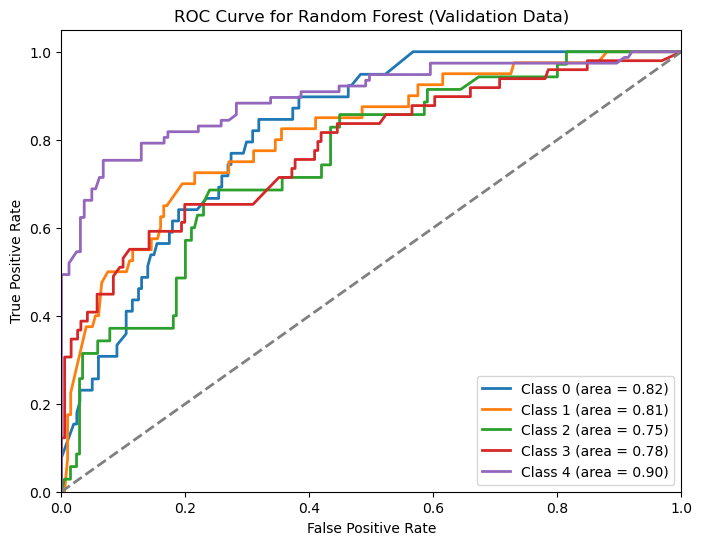

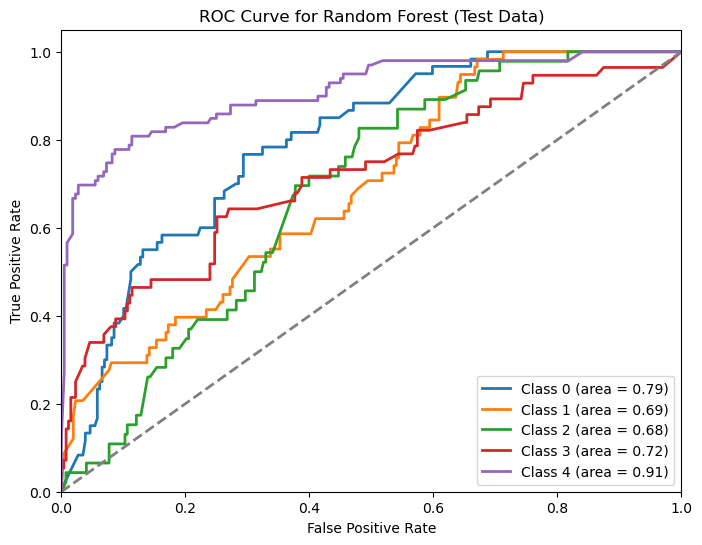

In [53]:
# Get the number of classes
n_classes = len(cp.unique(y_train).get())

# ROC and AUC
rf_pred_val_proba = best_rf.predict_proba(X_val_np)
rf_pred_test_proba = best_rf.predict_proba(X_test_np)

plot_multiclass_roc_curve(y_val_np, rf_pred_val_proba, n_classes, "ROC Curve for Random Forest (Validation Data)")
plot_multiclass_roc_curve(y_test_np, rf_pred_test_proba, n_classes, "ROC Curve for Random Forest (Test Data)")


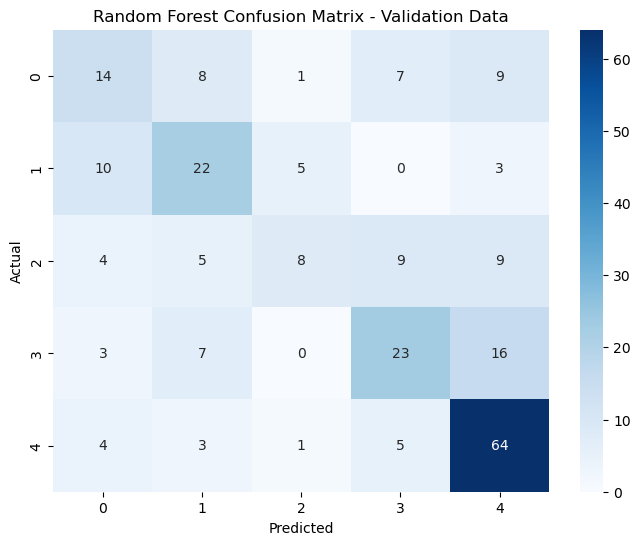

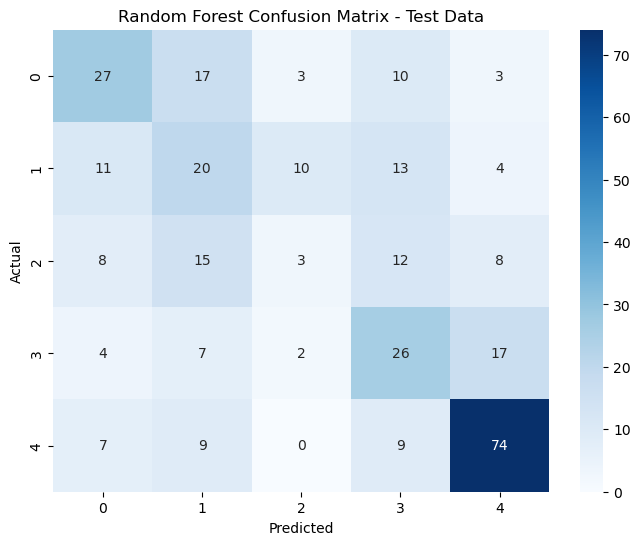

In [52]:
plot_confusion_matrix(y_val_np, rf_pred_val, 'Random Forest Confusion Matrix - Validation Data')
plot_confusion_matrix(y_test_np, rf_pred_test, 'Random Forest Confusion Matrix - Test Data')

## Gradient Boosting

In [ ]:
from cuml.ensemble import GradientBoostingClassifier as cuGB

# Gradient Boosting Classifier
param_grid_gb = {'n_estimators': range(10,101), 
                 'max_depth': range(1,51),
                 'min_samples_split': [2, 5, 10],
                 'min_samples_leaf': [1, 2, 4, 6], 
                 'max_features': ['auto', 'sqrt', 0.25, 0.5, 1] 
                }

gb = cuGB()
grid_search_gb = GridSearchCV(gb, param_grid_gb, cv=3, return_train_score=True, scoring='accuracy')
grid_search_gb.fit(X_train_np, y_train_np)

print("Best parameters for Gradient Boosting: ", grid_search_gb.best_params_)

best_gb = grid_search_gb.best_estimator_
gb_pred_val = best_gb.predict(X_val_np)
gb_val_acc = accuracy_score(y_val_np, gb_pred_val)

print(f"Gradient Boosting Validation Accuracy with best parameters: {gb_val_acc}")
print("Classification Report for Gradient Boosting:")
print(classification_report(y_val_np, gb_pred_val))

# Evaluate on test set
gb_pred_test = best_gb.predict(X_test_np)
gb_test_acc = accuracy_score(y_test_np, gb_pred_test)
print(f"Gradient Boosting Test Accuracy with best parameters: {gb_test_acc}")
print("Classification Report for Gradient Boosting on Test Data:")
print(classification_report(y_test_np, gb_pred_test))

In [ ]:
plot_confusion_matrix(y_val_np, gb_pred_val, 'Gradient Boosting Confusion Matrix - Validation Data')
plot_confusion_matrix(y_test_np, gb_pred_test, 'Gradient Boosting Confusion Matrix - Test Data')

## K-Nearest Neighbors (KNN)

In [54]:
from cuml.neighbors import KNeighborsClassifier as cuKNN

# Custom wrapper to remove n_jobs
class CuKNNWrapper(cuKNN):
    def __init__(self, **kwargs):
        if 'n_jobs' in kwargs:
            kwargs.pop('n_jobs')
        super().__init__(**kwargs)

# K-Nearest Neighbors Classifier
param_grid_knn = {
    'n_neighbors': range(1, 30),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

knn = CuKNNWrapper()

grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=3, return_train_score=True, scoring='accuracy')
grid_search_knn.fit(X_train_np, y_train_np)

print("Best parameters for KNN: ", grid_search_knn.best_params_)

best_knn = grid_search_knn.best_estimator_
knn_pred_val = best_knn.predict(X_val_np)
knn_val_acc = accuracy_score(y_val_np, knn_pred_val)

print(f"KNN Validation Accuracy with best parameters: {knn_val_acc}")
print("Classification Report for KNN:")
print(classification_report(y_val_np, knn_pred_val))

# Evaluate on test set
knn_pred_test = best_knn.predict(X_test_np)
knn_test_acc = accuracy_score(y_test_np, knn_pred_test)
print(f"KNN Test Accuracy with best parameters: {knn_test_acc}")
print("Classification Report for KNN on Test Data:")
print(classification_report(y_test_np, knn_pred_test))


/home/phatthapol/miniconda3/envs/rapids-24.06/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
1044 fits failed out of a total of 1392.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1044 fits failed with the following error:
Traceback (most recent call last):
  File "/home/phatthapol/miniconda3/envs/rapids-24.06/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/phatthapol/miniconda3/envs/rapids-24.06/lib/python3.10/site-packages/cuml/internals/api_decorators.py", line 188, in wrapper
    ret = func(*args, **kwargs)
  File "kneighbors_classifier.pyx", line 166, in cuml.neighbors.kneig

Best parameters for KNN:  {'algorithm': 'auto', 'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}
KNN Validation Accuracy with best parameters: 0.5041666666666667
Classification Report for KNN:
              precision    recall  f1-score   support

         0.0       0.42      0.26      0.32        39
         1.0       0.36      0.40      0.38        40
         2.0       0.27      0.26      0.26        35
         3.0       0.47      0.55      0.50        49
         4.0       0.74      0.77      0.75        77

    accuracy                           0.50       240
   macro avg       0.45      0.45      0.44       240
weighted avg       0.50      0.50      0.50       240

KNN Test Accuracy with best parameters: 0.44200626959247646
Classification Report for KNN on Test Data:
              precision    recall  f1-score   support

         0.0       0.47      0.23      0.31        60
         1.0       0.29      0.36      0.32        58
         2.0       0.12      0.11      0.12        4

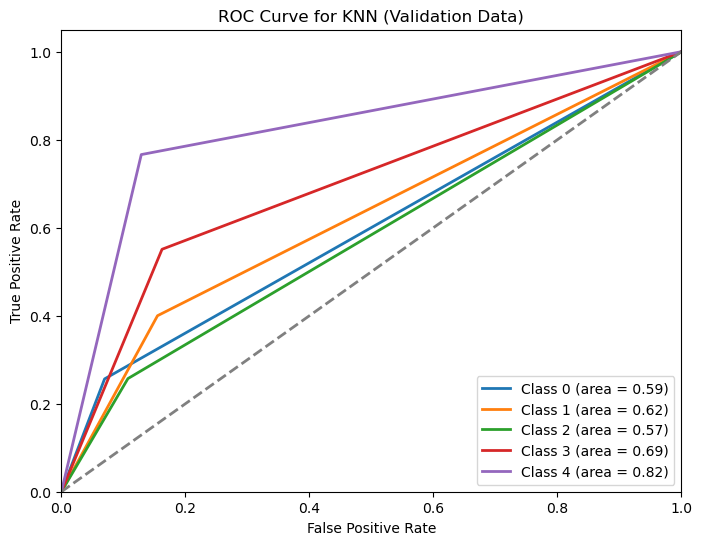

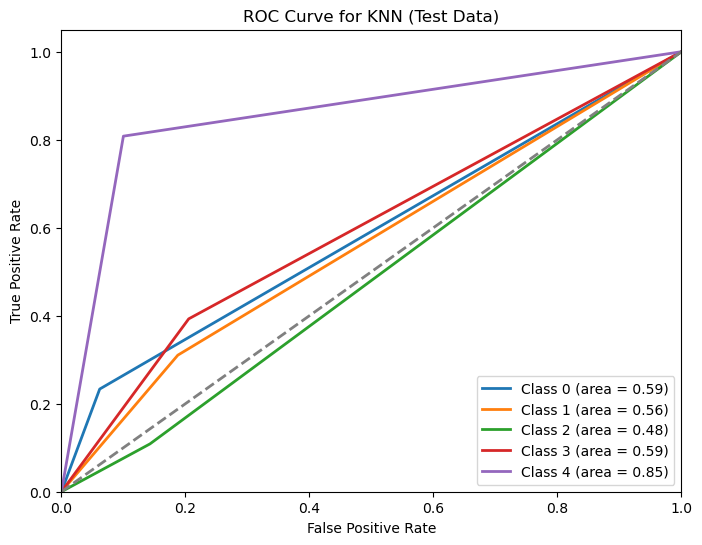

In [56]:
# Get the number of classes
n_classes = len(cp.unique(y_train).get())

# ROC and AUC
rf_pred_val_proba = best_knn.predict_proba(X_val_np)
rf_pred_test_proba = best_knn.predict_proba(X_test_np)

plot_multiclass_roc_curve(y_val_np, rf_pred_val_proba, n_classes, "ROC Curve for KNN (Validation Data)")
plot_multiclass_roc_curve(y_test_np, rf_pred_test_proba, n_classes, "ROC Curve for KNN (Test Data)")

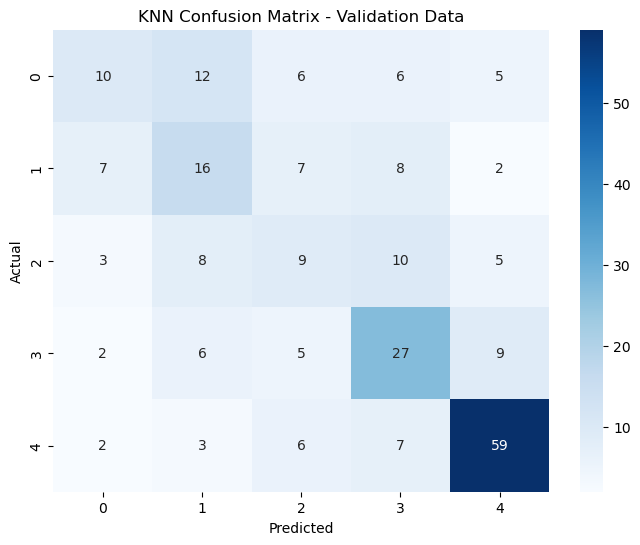

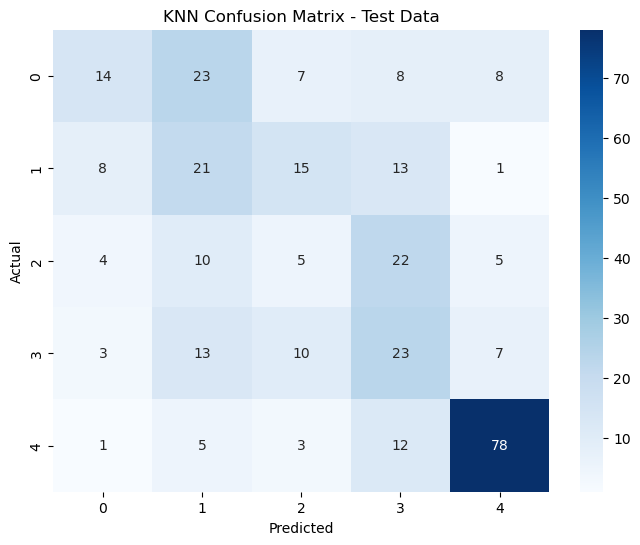

In [57]:
plot_confusion_matrix(y_val_np, knn_pred_val, 'KNN Confusion Matrix - Validation Data')
plot_confusion_matrix(y_test_np, knn_pred_test, 'KNN Confusion Matrix - Test Data')

## Support Vector Machine (SVM)

In [58]:
from cuml.svm import SVC as cuSVM
from sklearn.metrics import accuracy_score, classification_report

print("Best parameters for SVM:  {'C': '1', 'gamma': 0.01, 'degree': 3, 'coef0': '0.0'}")
# ตั้งค่าพารามิเตอร์ของ SVM
C = 1
gamma = 0.01
degree = 3

# สร้างโมเดล SVM
svm = cuSVM(C=C, gamma=gamma, degree=degree, probability=True)

# ฝึกโมเดลด้วยข้อมูลฝึก
svm.fit(X_train_np, y_train_np)

# ทำนายค่าด้วยข้อมูล validation
svm_pred_val = svm.predict(X_val_np)
svm_val_acc = accuracy_score(y_val_np, svm_pred_val)

print(f"SVM Validation Accuracy: {svm_val_acc}")
print("Classification Report for SVM:")
print(classification_report(y_val_np, svm_pred_val))

# ทำนายค่าด้วยข้อมูลทดสอบ
svm_pred_test = svm.predict(X_test_np)
svm_test_acc = accuracy_score(y_test_np, svm_pred_test)
print(f"SVM Test Accuracy: {svm_test_acc}")
print("Classification Report for SVM on Test Data:")
print(classification_report(y_test_np, svm_pred_test))


Best parameters for SVM:  {'C': '1', 'gamma': 0.01, 'degree': 3, 'coef0': '0.0'}
SVM Validation Accuracy: 0.45416666666666666
Classification Report for SVM:
              precision    recall  f1-score   support

         0.0       0.35      0.49      0.41        39
         1.0       0.46      0.28      0.34        40
         2.0       0.00      0.00      0.00        35
         3.0       0.37      0.29      0.32        49
         4.0       0.52      0.84      0.65        77

    accuracy                           0.45       240
   macro avg       0.34      0.38      0.34       240
weighted avg       0.38      0.45      0.40       240



/home/phatthapol/miniconda3/envs/rapids-24.06/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/phatthapol/miniconda3/envs/rapids-24.06/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/phatthapol/miniconda3/envs/rapids-24.06/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

SVM Test Accuracy: 0.48589341692789967
Classification Report for SVM on Test Data:
              precision    recall  f1-score   support

         0.0       0.41      0.52      0.46        60
         1.0       0.34      0.26      0.29        58
         2.0       0.00      0.00      0.00        46
         3.0       0.43      0.41      0.42        56
         4.0       0.59      0.87      0.70        99

    accuracy                           0.49       319
   macro avg       0.35      0.41      0.37       319
weighted avg       0.40      0.49      0.43       319



/home/phatthapol/miniconda3/envs/rapids-24.06/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/phatthapol/miniconda3/envs/rapids-24.06/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/phatthapol/miniconda3/envs/rapids-24.06/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

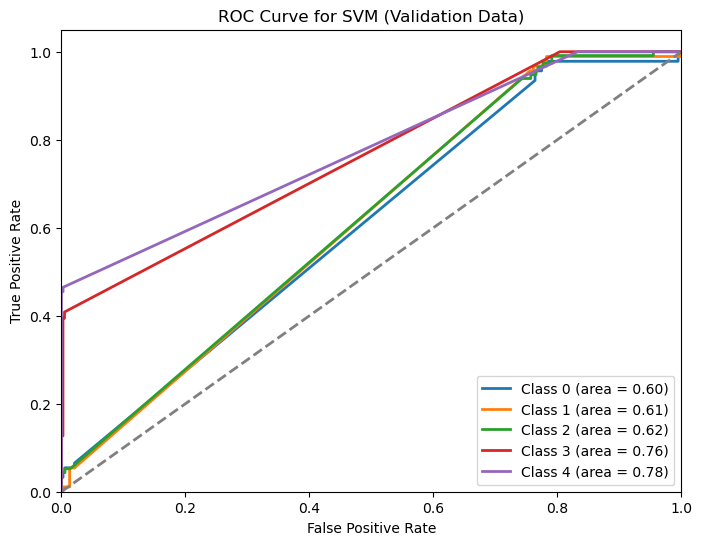

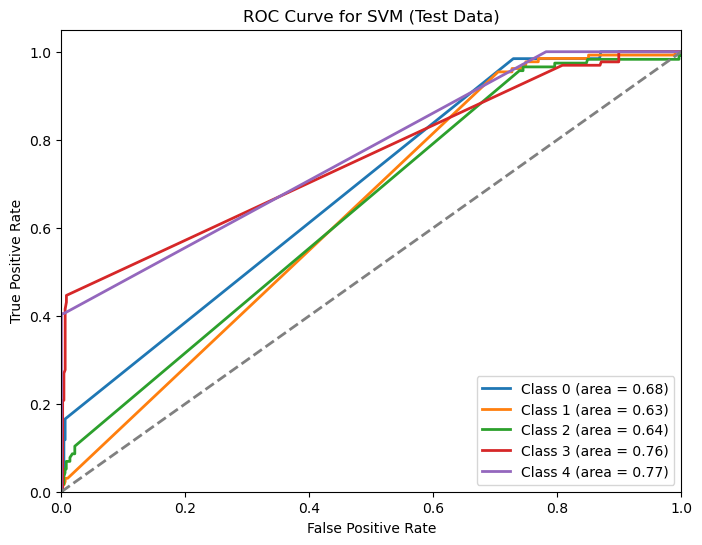

In [21]:
# Get the number of classes
n_classes = len(cp.unique(y_train).get())

# ROC and AUC
rf_pred_val_proba = svm.predict_proba(X_val_np)
rf_pred_test_proba = svm.predict_proba(X_test_np)

plot_multiclass_roc_curve(y_val_np, rf_pred_val_proba, n_classes, "ROC Curve for SVM (Validation Data)")
plot_multiclass_roc_curve(y_test_np, rf_pred_test_proba, n_classes, "ROC Curve for SVM (Test Data)")

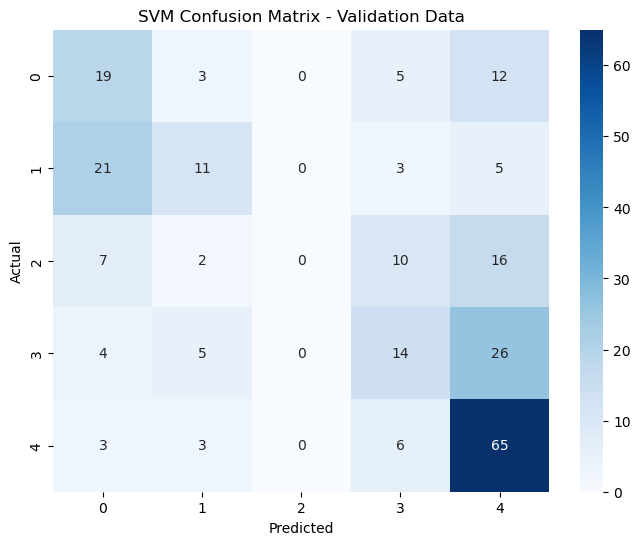

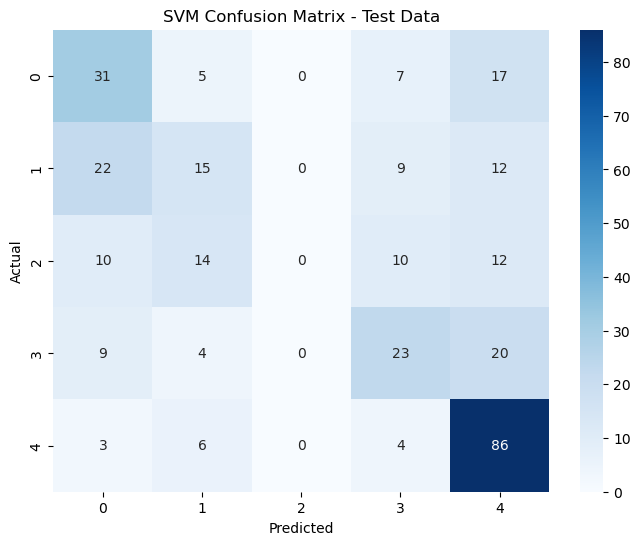

In [59]:
plot_confusion_matrix(y_val_np, svm_pred_val, 'SVM Confusion Matrix - Validation Data')
plot_confusion_matrix(y_test_np, svm_pred_test, 'SVM Confusion Matrix - Test Data')

In [ ]:
from cuml.svm import SVC as cuSVM
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Support Vector Machine Classifier
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1],
    'degree': [2, 3],
    'coef0': [0.0, 0.1, 0.5]
}

svm = cuSVM(probability=True)
grid_search_svm = GridSearchCV(svm, param_grid_svm, cv=3, return_train_score=True, scoring='accuracy')
grid_search_svm.fit(X_train_np, y_train_np)

print("Best parameters for SVM: ", grid_search_svm.best_params_)

best_svm = grid_search_svm.best_estimator_
svm_pred_val = best_svm.predict(X_val_np)
svm_val_acc = accuracy_score(y_val_np, svm_pred_val)

print(f"SVM Validation Accuracy with best parameters: {svm_val_acc}")
print("Classification Report for SVM:")
print(classification_report(y_val_np, svm_pred_val))

# Evaluate on test set
svm_pred_test = best_svm.predict(X_test_np)
svm_test_acc = accuracy_score(y_test_np, svm_pred_test)
print(f"SVM Test Accuracy with best parameters: {svm_test_acc}")
print("Classification Report for SVM on Test Data:")
print(classification_report(y_test_np, svm_pred_test))


In [ ]:
plot_confusion_matrix(y_val_np, svm_pred_val, 'SVM Confusion Matrix - Validation Data')
plot_confusion_matrix(y_test_np, svm_pred_test, 'SVM Confusion Matrix - Test Data')

## Naive Bayes

In [29]:
from cuml.naive_bayes import MultinomialNB as cuNB

# Naive Bayes Classifier
param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]
}

nb = cuNB()
grid_search_nb = GridSearchCV(nb, param_grid_nb, cv=3, return_train_score=True, scoring='accuracy')
grid_search_nb.fit(X_train_np, y_train_np)

print("Best parameters for MultinomialNB: ", grid_search_nb.best_params_)

best_nb = grid_search_nb.best_estimator_
nb_pred_val = best_nb.predict(X_val_np)
nb_val_acc = accuracy_score(y_val_np, nb_pred_val)

print(f"Naive Bayes Validation Accuracy: {nb_val_acc}")
print("Classification Report for Naive Bayes:")
print(classification_report(y_val_np, nb_pred_val))

# Evaluate on test set
nb_pred_test = best_nb.predict(X_test_np)
nb_test_acc = accuracy_score(y_test_np, nb_pred_test)
print(f"Naive Bayes Test Accuracy: {nb_test_acc}")
print("Classification Report for Naive Bayes on Test Data:")
print(classification_report(y_test_np, nb_pred_test))


Best parameters for MultinomialNB:  {'alpha': 0.1}
Naive Bayes Validation Accuracy: 0.27292110874200426
Classification Report for Naive Bayes:
              precision    recall  f1-score   support

         0.0       0.32      0.24      0.27        92
         1.0       0.24      0.66      0.36        92
         2.0       0.24      0.08      0.12       115
         3.0       0.17      0.13      0.14        71
         4.0       0.47      0.27      0.34        99

    accuracy                           0.27       469
   macro avg       0.29      0.28      0.25       469
weighted avg       0.29      0.27      0.25       469

Naive Bayes Test Accuracy: 0.2896
Classification Report for Naive Bayes on Test Data:
              precision    recall  f1-score   support

         0.0       0.30      0.24      0.27       127
         1.0       0.27      0.66      0.38       131
         2.0       0.15      0.05      0.08       116
         3.0       0.28      0.16      0.20       130
         4.

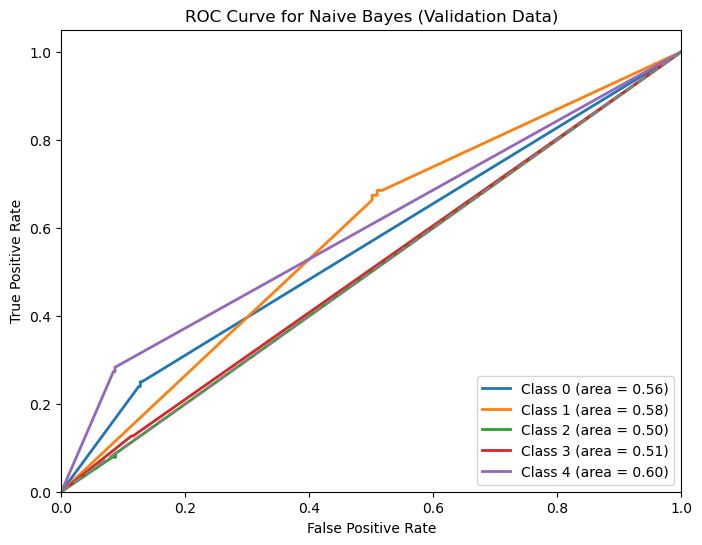

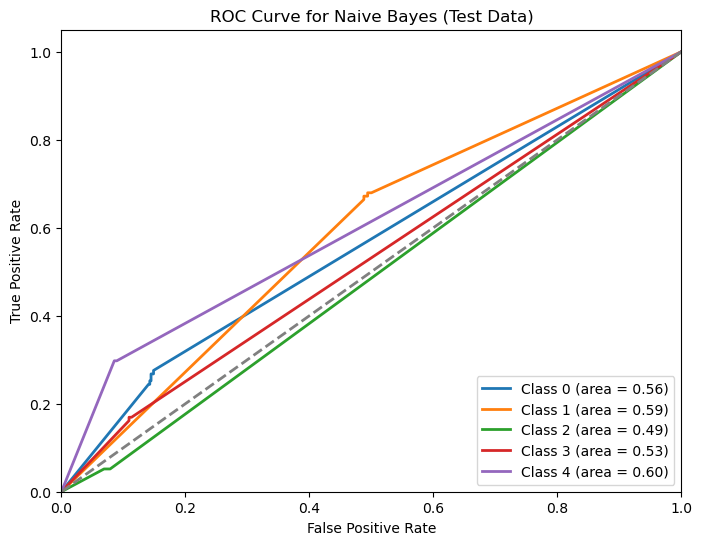

In [30]:
# Get the number of classes
n_classes = len(cp.unique(y_train).get())

# ROC and AUC
rf_pred_val_proba = best_nb.predict_proba(X_val_np)
rf_pred_test_proba = best_nb.predict_proba(X_test_np)

plot_multiclass_roc_curve(y_val_np, rf_pred_val_proba, n_classes, "ROC Curve for Naive Bayes (Validation Data)")
plot_multiclass_roc_curve(y_test_np, rf_pred_test_proba, n_classes, "ROC Curve for Naive Bayes (Test Data)")

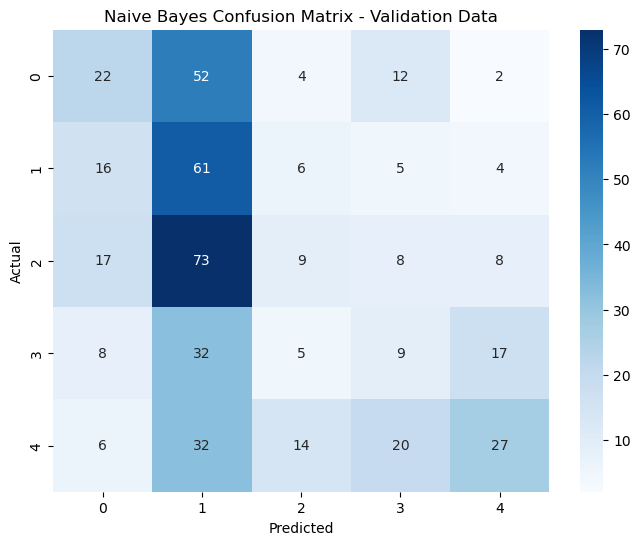

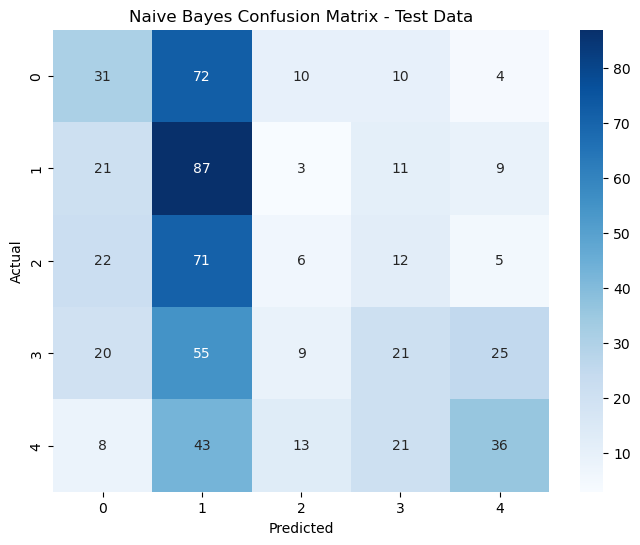

In [31]:
plot_confusion_matrix(y_val_np, nb_pred_val, 'Naive Bayes Confusion Matrix - Validation Data')
plot_confusion_matrix(y_test_np, nb_pred_test, 'Naive Bayes Confusion Matrix - Test Data')

## Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Define the model and parameters for GridSearchCV
model = LogisticRegression(solver='saga', max_iter=10000)  # saga solver supports elasticnet
param_grid = {
    'penalty': ['elasticnet'],
    'C': [0.1, 1.0, 10.0],
    'l1_ratio': [0.2, 0.5, 0.8]  # L1 ratio for Elastic Net
}

# Perform GridSearchCV
grid_search_lr = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_train_np, y_train_np)

print("Best parameters for Logistic Regression: ", grid_search_lr.best_params_)

# Use the best estimator
best_lr = grid_search_lr.best_estimator_
lr_pred_val = best_lr.predict(X_val_np)
lr_val_acc = accuracy_score(y_val_np, lr_pred_val)

print(f"Logistic Regression Validation Accuracy: {lr_val_acc}")
print("Classification Report Logistic Regression:")
print(classification_report(y_val_np, lr_pred_val))

# Evaluate on test set
lr_pred_test = best_lr.predict(X_test_np)
lr_test_acc = accuracy_score(y_test_np, lr_pred_test)
print(f"Logistic Regression Test Accuracy: {lr_test_acc}")
print("Classification Report Logistic Regression on Test Data:")
print(classification_report(y_test_np, lr_pred_test))


Best parameters for Logistic Regression:  {'C': 1.0, 'l1_ratio': 0.5, 'penalty': 'elasticnet'}
Logistic Regression Validation Accuracy: 0.2814498933901919
Classification Report Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.29      0.22      0.25        92
         1.0       0.31      0.20      0.24        92
         2.0       0.23      0.16      0.19       115
         3.0       0.20      0.49      0.28        71
         4.0       0.50      0.41      0.45        99

    accuracy                           0.28       469
   macro avg       0.30      0.30      0.28       469
weighted avg       0.31      0.28      0.28       469

Logistic Regression Test Accuracy: 0.2368
Classification Report Logistic Regression on Test Data:
              precision    recall  f1-score   support

         0.0       0.30      0.21      0.25       127
         1.0       0.19      0.13      0.16       131
         2.0       0.17      0.15      0.16       11

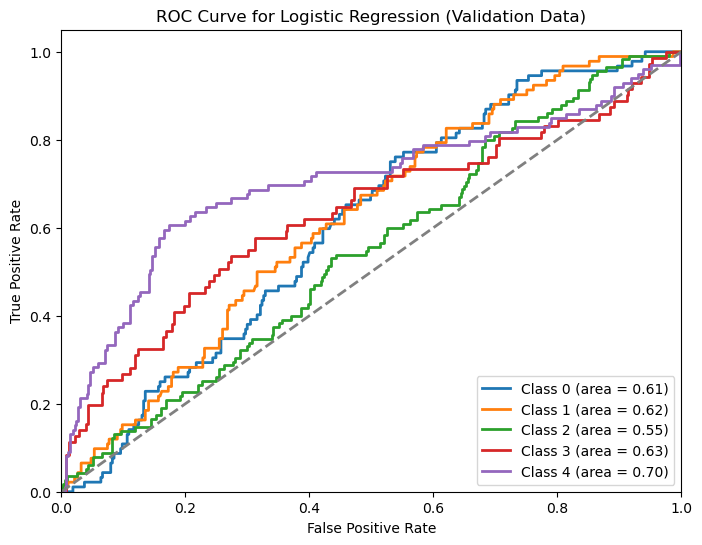

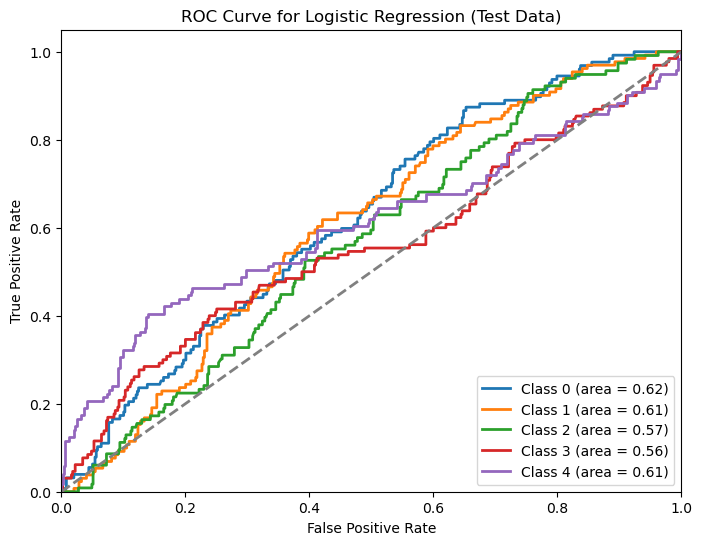

In [27]:
# Get the number of classes
n_classes = len(cp.unique(y_train).get())

# ROC and AUC
rf_pred_val_proba = best_lr.predict_proba(X_val_np)
rf_pred_test_proba = best_lr.predict_proba(X_test_np)

plot_multiclass_roc_curve(y_val_np, rf_pred_val_proba, n_classes, "ROC Curve for Logistic Regression (Validation Data)")
plot_multiclass_roc_curve(y_test_np, rf_pred_test_proba, n_classes, "ROC Curve for Logistic Regression (Test Data)")

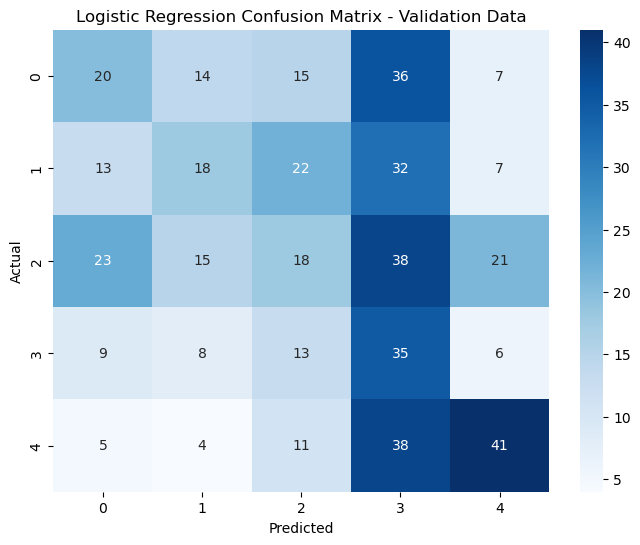

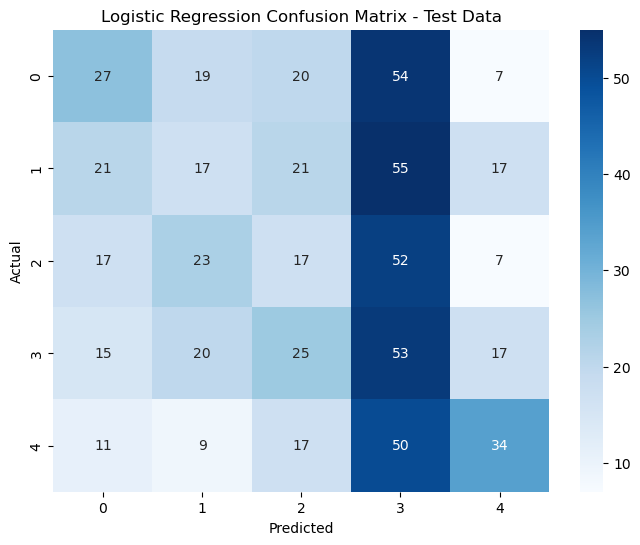

In [28]:
plot_confusion_matrix(y_val_np, lr_pred_val, 'Logistic Regression Confusion Matrix - Validation Data')
plot_confusion_matrix(y_test_np, lr_pred_test, 'Logistic Regression Confusion Matrix - Test Data')